# 263: combiner C, a consensus vote across alphabet-ksize pairs

Input: the table [notebook 260](260_kmerseek_region_table.ipynb) writes, one row per human
query, target species, merged region and alphabet-ksize pair (one reduced amino-acid
alphabet at one k-mer size; the column is `arm`). A merged region is the stretch of the
query that overlapping kmerseek calls cover, joined across every pair.

**Combiner C.** For each merged region, `n_votes` is the number of pairs that call it at
`region_evalue` < E_max. Regions are ranked by `n_votes` (most first); ties go to the
lower corrected E-value from [notebook 262](262_combiner_b_best_of_n.ipynb), which is the
number of pairs searched on that query and species times the lowest E-value any pair gave
the region. A region is called when `n_votes` >= v_min. Combiner A
([notebook 261](261_combiner_a_intersection_panel.ipynb)) needs every pair of a fixed panel;
combiner B (notebook 262) needs one pair. C needs v_min of them, any v_min.

`region_evalue` is kmerseek's Karlin-Altschul E-value: how many regions scoring at least
this well a search of the same database would find by chance. A shuffled query is the human
protein with its residues shuffled in pairs (dipeptides); it has no true homolog, so every
region called on it is a false call.

**Votes are not independent.** Two pairs with the same alphabet and a neighbouring k, or two
alphabets that differ by one or two residues, call the same regions. A region they both call
gets two votes for what is one piece of evidence. So every result is given twice: once
counting every pair, and once counting one vote per cluster of pairs. Agreement between two
pairs = merged regions both call / merged regions either calls. A cluster is a set of pairs
in which every two agree on more than 80% (complete-linkage clustering on 1 - agreement,
cut at 0.2).

**Truth**, as in notebooks 261 and 262. A merged region is a true call when at least half
of it lies inside one feature of the truth set. Two truth sets: Swiss-Prot features (DOMAIN,
REGION, TRANSMEM, REPEAT, BINDING and the rest) and Pfam domains.
- Precision = true calls / calls, over calls on queries that have at least one feature in
  that set. Higher is fewer false calls.
- Recall = features with at least one called region landed inside / all features on the
  split's queries, once per target species. Higher is more features found.

**Procedure and decision rules, fixed before running.**
1. Tune split only. For E_max in {0.1, 1, 10} and v_min from 1 to the number of pairs (or
   clusters): calls, precision and recall in both truth sets, and calls on the shuffled
   queries at the same (E_max, v_min).
2. The vote count to use at each E_max is the smallest v_min where shuffled-query calls are
   at most 5% of real calls. Without shuffled-query calls, it is the smallest v_min with tune
   Swiss-Prot precision >= 0.5, or Pfam precision >= 0.5 when no setting reaches 0.5 on
   Swiss-Prot (notebook 262's fallback).
3. Freeze the (E_max, counting) with the most tune calls at its vote count; ties go to one
   vote per cluster, then to the smaller E_max. Save it to `263_consensus_vote.yaml`.
4. If counting every pair and counting one per cluster freeze different settings, trust one
   per cluster, unless the shuffled queries show it lets through more false calls at the
   same number of real calls. The reason: a vote from a near copy of a pair already counted
   adds no new evidence, and only the clustered count knows that.
5. Report the frozen setting on test beside combiners A and B, the best single pair, and on
   multi-domain queries beside phmmer. No choice is made on test.
6. Known cases, from notebook 241's search: Ced9 (query) against BCL2 at the BH1 motif,
   P66 (query) against CD47 at the P66 loop and CD47 contact span, and BHF's regions from
   [PR #44](https://github.com/seanome/2024-kmerseek-analysis/pull/44). Where each falls in the vote ranking, with the real residues of the top voting
   pair's call.

The split is by query: `tune` or `test` by the first byte of SHA-1 of the accession
(notebook 260). A shuffled query goes to its source protein's half.

## Which data this execution reads

Sections 1 to 6 read notebook 260's table. The kmerseek 0.4 midi-plus run with extension
(`make run-midi-plus-0.4-extend`, [PR #88](https://github.com/seanome/2024-kmerseek-analysis/pull/88)) and its shuffled-query twin (`M04_RUN=decoy`) have
not run, so, as in notebooks 261 and 262, the table has four pairs, all one alphabet at one
k: hp_pbotc_1st_ed2 at k=19 against zebrafish, at extension penalties 1.63 and 2, each run
with the built-in alphabet and with the same two-letter partition given as already-encoded
sequences (`encoded_`). What that means here:
- At most 4 votes, from near-copies of one search.
- No shuffled-query calls, so step 2 falls back to precision, and the shuffled-query lines
  in the main figure are empty.
- Every number is zebrafish only.

The code reads whatever `region_table.parquet` and `reduced_decoy/` hold, so the notebook
reruns unchanged on the full run.

Section 7 reads [notebook 241](https://github.com/seanome/2024-kmerseek-analysis/pull/46) (`241_alphabet_ranking_BCL2-Ced9_P66-CD47_BHF.ipynb`)'s search instead,
because notebook 260's table has no Ced9, P66 or BHF (its queries are human). Notebook 241
searched Ced9, P66 and BHF against GENCODE v49 canonical human proteins (19_732) at 152
pairs, 19 alphabets with k chosen per alphabet (2026-09-23,
`~/data/botryllus/alphabet-ranking-three-cases/regions.parquet`). There, a merged region is
merged per query and target protein, so every merged region names its target.

phmmer (HMMER3 single-sequence search) for the multi-domain section comes from the
midi-plus region benchmark run (1-2 Sept 2026): the same human queries against the zebrafish
proteome, per-domain hits with their i-Evalue.

In [1]:
import hashlib
import sys
from datetime import date
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path.cwd()))
import mhc_region_utils as mu
import pubfig as pf
import region_combiner_261 as rc
import region_combiner_262 as rb
import region_combiner_263 as rv
import region_table_260 as rt

pf.use_style()

def notebook_figure(fig, stem: Path, **kw) -> None:
    # The paper version (pdf, svg, png; no header) first; then freeze the layout and save
    # the notebook version with mu.finish_figure's TOOLS, hypothesis and conclusion.
    pf.save(fig, stem)
    fig.canvas.draw()
    fig.set_layout_engine("none")
    # A legend placed "outside" follows the figure edge, which the header moves; pin it.
    for leg in fig.legends:
        bb = leg.get_window_extent().transformed(fig.transFigure.inverted())
        leg.set_bbox_to_anchor(bb.bounds, transform=fig.transFigure)
        leg.set_loc("center")
    mu.finish_figure(fig, stem.with_name(stem.name + "_notebook.png"), layout=False, **kw)

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

BASE = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "260_region_table"
TABLE = BASE / "region_table.parquet"
TRUTH_PAIRS = BASE / "region_table_truth_pairs.parquet"
REDUCED = BASE / "reduced"
DECOY_REDUCED = BASE / "reduced_decoy"
PFAM_TRUTH = mu.MIDI_DIR / "truth" / "human_domain_truth.parquet"
SWISSPROT_TRUTH = mu.MIDI_DIR / "truth_swissprot" / "human_swissprot_truth.parquet"
QUERY_MAP = mu.MIDI_DIR / "query_gene_map.parquet"
PHMMER_DIR = mu.MIDI_DIR / "regions" / "hmmer3_phmmer"
PANEL_A_YAML = Path.cwd() / "261_intersection_panel.yaml"
B_YAML = Path.cwd() / "262_best_of_n_threshold.yaml"
OUT_YAML = Path.cwd() / "263_consensus_vote.yaml"
FIG = Path.cwd().parent / "figures"

def sha256(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()

table = pl.read_parquet(TABLE)
truth_pairs = pl.read_parquet(TRUTH_PAIRS)
truth = rt.load_truth(PFAM_TRUTH, SWISSPROT_TRUTH)
summary = pl.read_parquet(REDUCED / "reduce_summary.parquet")
tried = rb.arms_tried(summary)
calls = rb.merged_calls(REDUCED, table)  # raises if the re-merge differs from the table
scores = rb.attach_truth(rb.region_scores(calls, tried), table)
queries = pl.read_parquet(QUERY_MAP).select("accession", "hgnc_symbol")
SPECIES = sorted(scores["species"].unique().to_list())
ARMS = sorted(calls["arm"].unique().to_list())
per_arm = rv.per_arm_best(calls)
if DECOY_REDUCED.exists():
    d_calls = rb.merged_calls(DECOY_REDUCED)
    decoy_per_arm = rv.per_arm_best(d_calls).with_columns(split=rt.query_split(pl.col("accession")))
else:
    decoy_per_arm = None

panel_a = yaml.safe_load(PANEL_A_YAML.read_text())
b_rec = yaml.safe_load(B_YAML.read_text())
for name, rec in (("261", panel_a), ("262", b_rec)):
    assert rec["input_table_sha256"] == sha256(TABLE), f"notebook {name} read a different table"

print(f"{TABLE}: {table.height:_} rows, sha256 {sha256(TABLE)[:16]}")
print(f"calls re-read from {REDUCED}: {calls.height:_}; merged regions {scores.height:_}")
print("pairs searched per target species (n_arms_tried):")
print(tried)
print(f"pairs with calls: {ARMS}")
print(f"species with calls: {SPECIES}")
print("merged regions by split:", scores.group_by("split").len().sort("split").to_dicts())
print(f"shuffled-query reduced files: {'present' if decoy_per_arm is not None else 'absent, ' + str(DECOY_REDUCED)}")
print(f"combiner A (nb 261): {panel_a['panel']} at E < {panel_a['emax']:g}")
print(f"combiner B (nb 262): {b_rec['rank_score']} <= {b_rec['threshold']:.4g}; single pair "
      f"{b_rec['single_pair']} at E <= {b_rec['single_pair_threshold']:.4g}")

/Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet: 6_140 rows, sha256 c936f3884dbbb25f
calls re-read from /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/reduced: 318_268; merged regions 1_713
pairs searched per target species (n_arms_tried):
shape: (2, 3)
┌───────────┬──────────────┬───────────────────────────────────────────────────────────────────────────────────┐
│ species   ┆ n_arms_tried ┆ arms_tried                                                                        │
│ ---       ┆ ---          ┆ ---                                                                               │
│ str       ┆ u32          ┆ list[str]                                                                         │
╞═══════════╪══════════════╪═══════════════════════════════════════════════════════════════════════════════════╡
│ zebrafish ┆ 4            ┆ ["encoded_hp_pbotc_1st_ed2_k19_ext1.63", "encoded_hp_pbotc_1st_ed2_k19_ext2", … … │
│ fly       ┆ 

## 1. Agreement between pairs, and the clusters

For each E_max, on tune queries: the share of merged regions both pairs call, out of the
regions either calls, for every two pairs. 1 means the two pairs call exactly the same
regions. Rows and columns are in dendrogram order (complete linkage on 1 - agreement); a
black box marks each cluster, a set of pairs that all agree on more than 0.8. One vote per
cluster is counted from these clusters in every later section.

In [2]:
tune_keys = scores.filter(pl.col("split") == "tune").select(rv.KEY)
pa_tune = per_arm.join(tune_keys, on=rv.KEY)
CLUSTERS, AGREE = {}, {}
for e in rv.EMAX_GRID:
    j, n = rv.agreement(pa_tune, e, ARMS)
    cl, z = rv.clusters(j, ARMS)
    CLUSTERS[e], AGREE[e] = cl, (j, n, z)
    print(f"E_max {e:g}: calls per pair {dict(zip(ARMS, n.tolist()))}")
    print(pl.DataFrame(np.round(j, 3), schema=ARMS).with_columns(pl.Series("pair", ARMS)).select(["pair"] + ARMS))
    off = j[~np.eye(len(ARMS), dtype=bool)]
    print(f"  lowest agreement between two pairs {off.min():.3f}, highest {off.max():.3f}; "
          f"clusters: {len(set(cl.values()))} -> {cl}\n")

E_max 0.1: calls per pair {'encoded_hp_pbotc_1st_ed2_k19_ext1.63': 543, 'encoded_hp_pbotc_1st_ed2_k19_ext2': 576, 'hp_pbotc_1st_ed2_k19_ext1.63': 523, 'hp_pbotc_1st_ed2_k19_ext2': 560}
shape: (4, 5)
┌──────────────────────────────────────┬──────────────────────────────────────┬───────────────────────────────────┬──────────────────────────────┬───────────────────────────┐
│ pair                                 ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ encoded_hp_pbotc_1st_ed2_k19_ext2 ┆ hp_pbotc_1st_ed2_k19_ext1.63 ┆ hp_pbotc_1st_ed2_k19_ext2 │
│ ---                                  ┆ ---                                  ┆ ---                               ┆ ---                          ┆ ---                       │
│ str                                  ┆ f64                                  ┆ f64                               ┆ f64                          ┆ f64                       │
╞══════════════════════════════════════╪══════════════════════════════════════╪══════════════════════

short labels: {'encoded_hp_pbotc_1st_ed2_k19_ext1.63': 'encoded, C 1.63', 'encoded_hp_pbotc_1st_ed2_k19_ext2': 'encoded, C 2', 'hp_pbotc_1st_ed2_k19_ext1.63': 'built-in, C 1.63', 'hp_pbotc_1st_ed2_k19_ext2': 'built-in, C 2'}


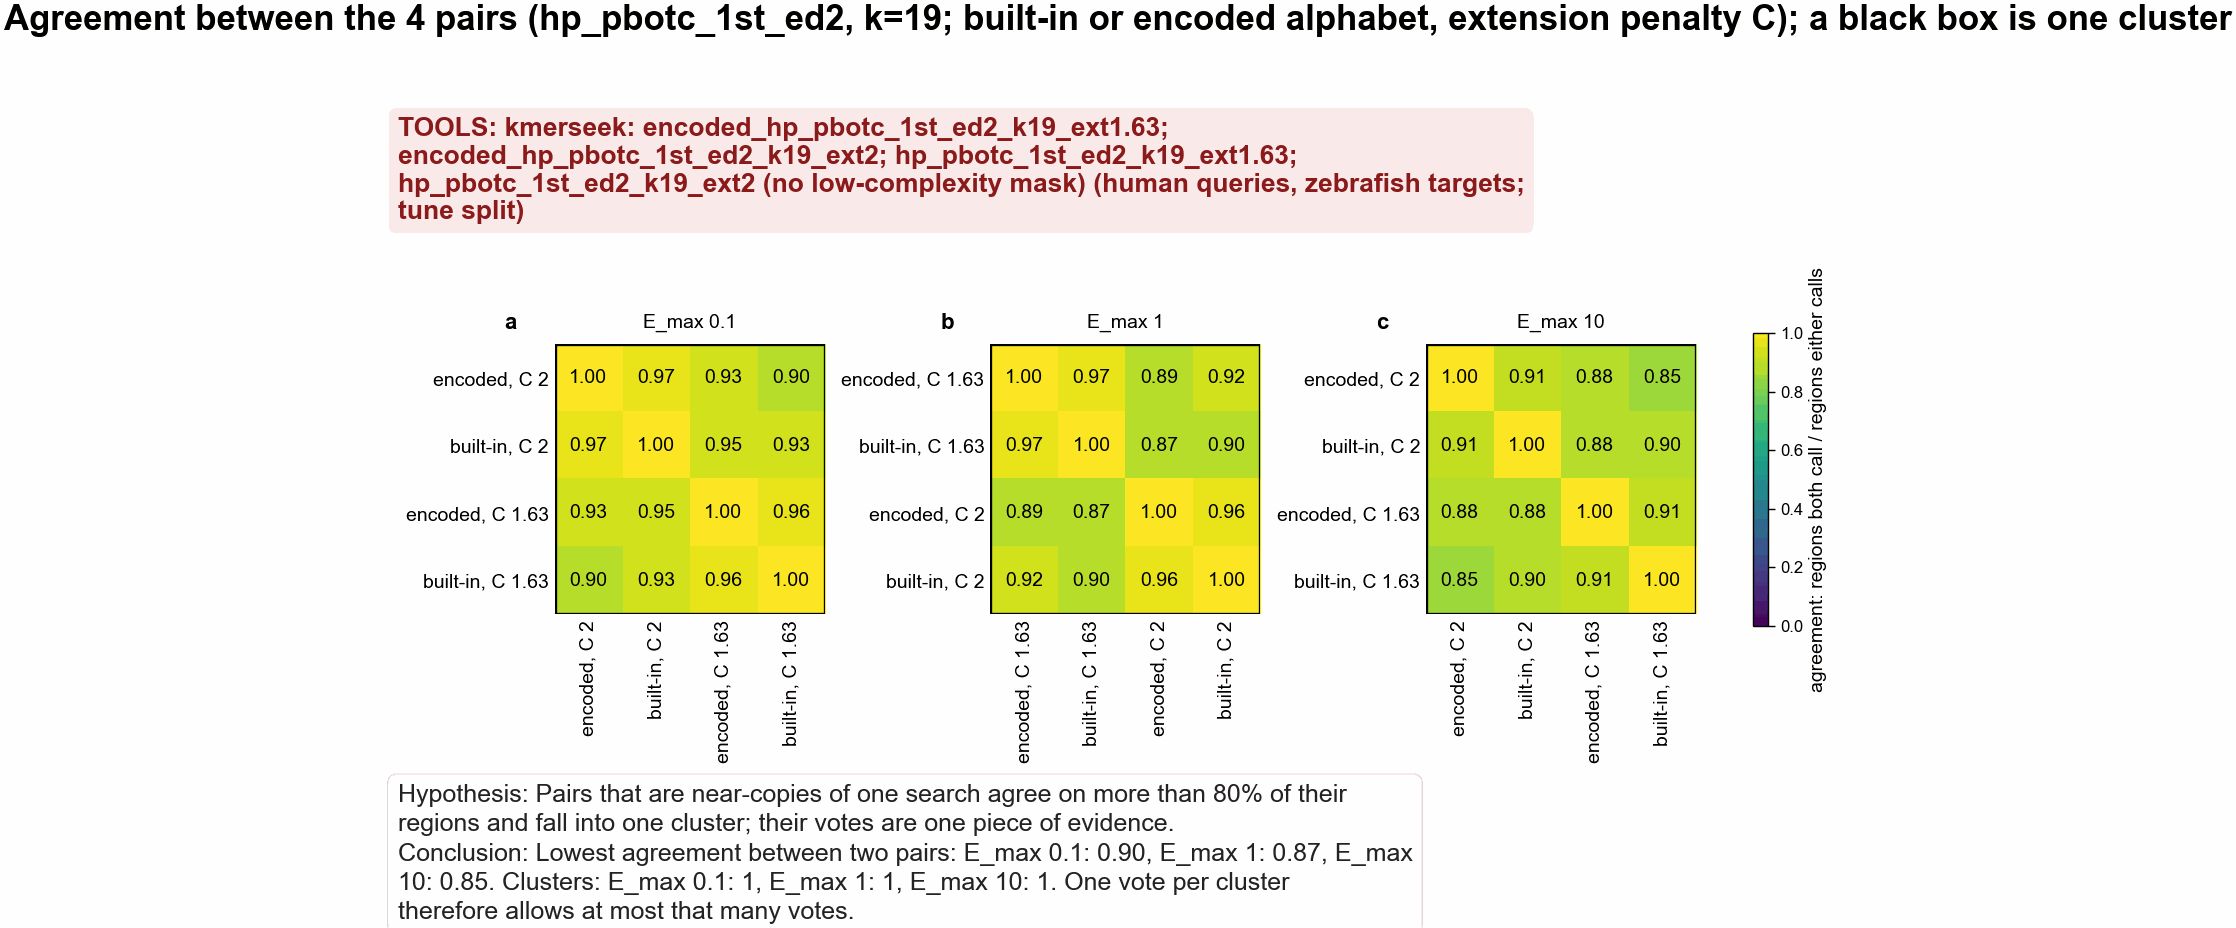

In [3]:
from scipy.cluster.hierarchy import leaves_list

def agreement_heatmap(ax, j, arms, cl, z, label_size=None, annotate=True):
    order = leaves_list(z) if z is not None else np.arange(len(arms))
    jj = j[np.ix_(order, order)]
    im = ax.imshow(jj, vmin=0, vmax=1, cmap="viridis", aspect="equal")
    names = [arms[i] for i in order]
    ax.set_xticks(range(len(names)), names, rotation=90, fontsize=label_size)
    ax.set_yticks(range(len(names)), names, fontsize=label_size)
    ax.tick_params(length=0)
    if annotate:
        for a in range(len(names)):
            for b in range(len(names)):
                ax.text(b, a, f"{jj[a, b]:.2f}", ha="center", va="center",
                        color="black" if jj[a, b] > 0.6 else "white")
    labs = [cl[n] for n in names]
    i = 0
    while i < len(labs):
        k = i
        while k + 1 < len(labs) and labs[k + 1] == labs[i]:
            k += 1
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), k - i + 1, k - i + 1, fill=False,
                                   edgecolor="black", lw=1.2))
        i = k + 1
    for s in ax.spines.values():
        s.set_visible(False)
    return im

SHORT = {a: ("encoded" if a.startswith("encoded_") else "built-in") + ", C " + a.rsplit("_ext", 1)[1] for a in ARMS}
print("short labels:", SHORT)
fig, axes = pf.figure(pf.TWO_COLUMN_MM, 70, ncols=3)
for ax, e, letter in zip(axes, rv.EMAX_GRID, "abc"):
    j, n, z = AGREE[e]
    im = agreement_heatmap(ax, j, [SHORT[a] for a in ARMS], {SHORT[a]: c for a, c in CLUSTERS[e].items()}, z)
    ax.set_title(f"E_max {e:g}")
    pf.panel_label(ax, letter)
cb = fig.colorbar(im, ax=axes, shrink=0.6, label="agreement: regions both call / regions either calls")
stem = FIG / "263_vote_pair_agreement_heatmap_zebrafish_tune"
lo = {e: AGREE[e][0][~np.eye(len(ARMS), dtype=bool)].min() for e in rv.EMAX_GRID}
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="human queries, zebrafish targets; tune split"),
    title="Agreement between the 4 pairs (hp_pbotc_1st_ed2, k=19; built-in or encoded alphabet, extension penalty C); a black box is one cluster",
    hypothesis="Pairs that are near-copies of one search agree on more than 80% of their "
               "regions and fall into one cluster; their votes are one piece of evidence.",
    conclusion=("Lowest agreement between two pairs: " +
                ", ".join(f"E_max {e:g}: {lo[e]:.2f}" for e in rv.EMAX_GRID) +
                ". Clusters: " + ", ".join(f"E_max {e:g}: {len(set(CLUSTERS[e].values()))}" for e in rv.EMAX_GRID) +
                ". One vote per cluster therefore allows at most that many votes."),

)

## 2. Calls, precision and recall at every (E_max, v_min) on tune

One row per E_max, way of counting votes, and v_min. `n_called` is merged regions with at
least v_min votes on tune queries; `n_decoy_called` the same on the shuffled tune queries
(empty until that run exists). Counting one vote per cluster stops at the number of
clusters.

In [4]:
nf_tune = rb.n_features(truth, "tune", len(SPECIES))
nf_test = rb.n_features(truth, "test", len(SPECIES))

def region_calls(split: str, nf: dict) -> rb.Calls:
    return rb.kmerseek_calls(scores.filter(pl.col("split") == split), truth_pairs, nf)

c_tune = region_calls("tune", nf_tune)
d_tune = decoy_per_arm.filter(pl.col("split") == "tune") if decoy_per_arm is not None else None
sw = rv.sweep(c_tune, pa_tune, d_tune, CLUSTERS, len(ARMS))
print(sw.select("emax", "counting", "v_min", "n_called", "n_decoy_called",
                "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam",
                "n_found_swissprot", "n_found_pfam"))

shape: (15, 11)
┌──────┬─────────────────┬───────┬──────────┬────────────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬───────────────────┬──────────────┐
│ emax ┆ counting        ┆ v_min ┆ n_called ┆ n_decoy_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ n_found_swissprot ┆ n_found_pfam │
│ ---  ┆ ---             ┆ ---   ┆ ---      ┆ ---            ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---               ┆ ---          │
│ f64  ┆ str             ┆ i64   ┆ i64      ┆ null           ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ i64               ┆ i64          │
╞══════╪═════════════════╪═══════╪══════════╪════════════════╪═════════════════════╪══════════════════╪════════════════╪═════════════╪═══════════════════╪══════════════╡
│ 0.1  ┆ every pair      ┆ 1     ┆ 579      ┆ null           ┆ 0.338798            ┆ 0.059058         ┆ 0.559585       ┆ 0.2352      ┆

shape: (12, 7)
┌──────┬───────┬──────────┬─────────────────────┬────────────────┬──────────────────┬─────────────┐
│ emax ┆ v_min ┆ n_called ┆ precision_swissprot ┆ precision_pfam ┆ recall_swissprot ┆ recall_pfam │
│ ---  ┆ ---   ┆ ---      ┆ ---                 ┆ ---            ┆ ---              ┆ ---         │
│ f64  ┆ i64   ┆ i64      ┆ f64                 ┆ f64            ┆ f64              ┆ f64         │
╞══════╪═══════╪══════════╪═════════════════════╪════════════════╪══════════════════╪═════════════╡
│ 0.1  ┆ 1     ┆ 579      ┆ 0.338798            ┆ 0.559585       ┆ 0.059058         ┆ 0.2352      │
│ 0.1  ┆ 2     ┆ 564      ┆ 0.33892             ┆ 0.556738       ┆ 0.057917         ┆ 0.2288      │
│ 0.1  ┆ 3     ┆ 538      ┆ 0.335283            ┆ 0.553903       ┆ 0.054208         ┆ 0.2192      │
│ 0.1  ┆ 4     ┆ 521      ┆ 0.331325            ┆ 0.556622       ┆ 0.051641         ┆ 0.2136      │
│ 1.0  ┆ 1     ┆ 673      ┆ 0.355243            ┆ 0.561664       ┆ 0.070185         ┆

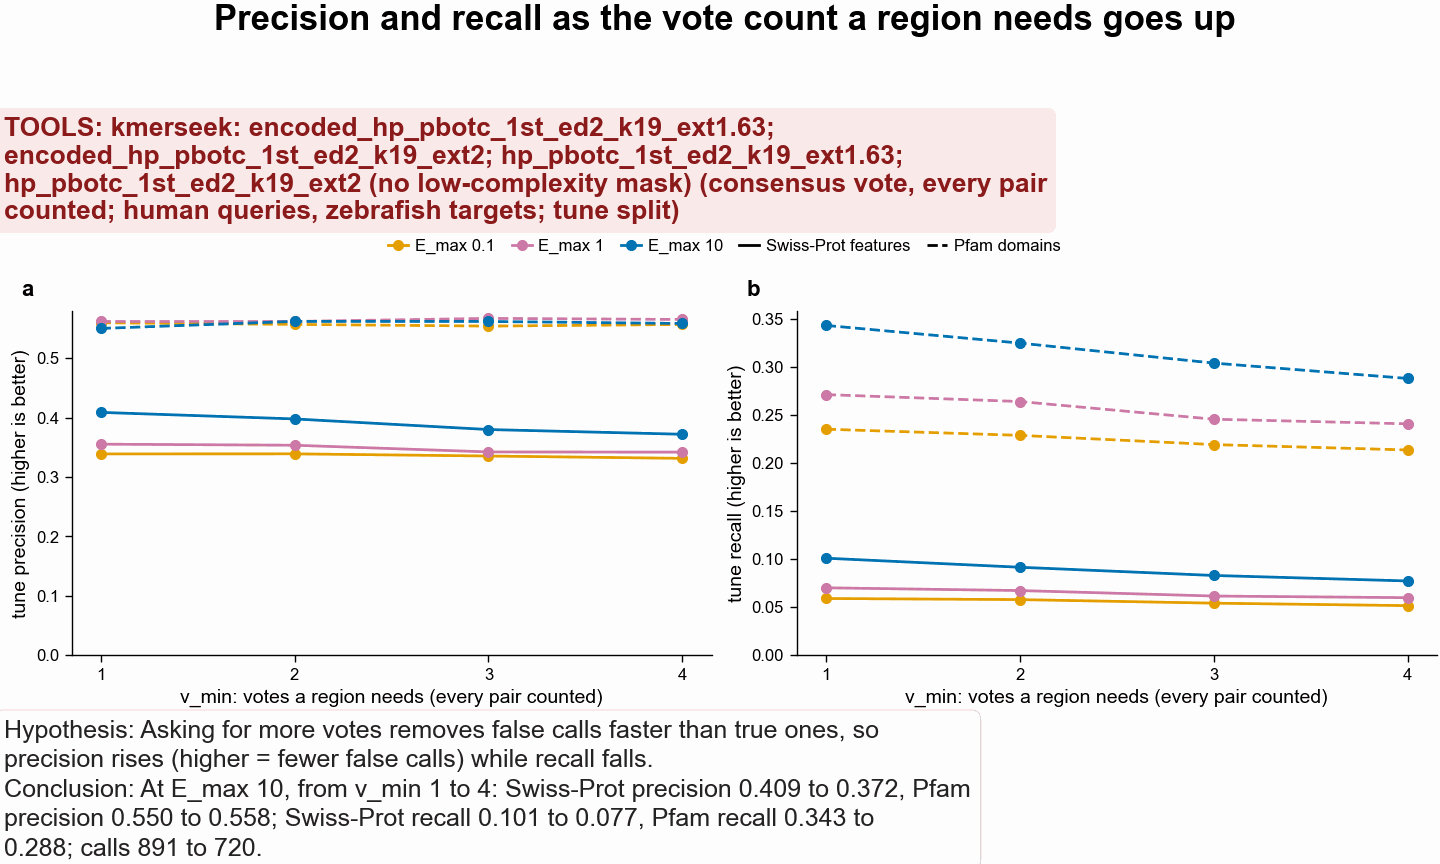

In [5]:
EMAX_C = {0.1: pf.OKABE_ITO["orange"], 1.0: pf.OKABE_ITO["reddish_purple"], 10.0: pf.OKABE_ITO["blue"]}
TS_LS = {"swissprot": "-", "pfam": "--"}
TS_NAME = {"swissprot": "Swiss-Prot features", "pfam": "Pfam domains"}
every = sw.filter(pl.col("counting") == "every pair")
print(every.select("emax", "v_min", "n_called", "precision_swissprot", "precision_pfam",
                   "recall_swissprot", "recall_pfam"))
fig, axes = pf.figure(pf.TWO_COLUMN_MM, 62, ncols=2)
for ax, what, letter in zip(axes, ("precision", "recall"), "ab"):
    for e in rv.EMAX_GRID:
        p = every.filter(pl.col("emax") == e).sort("v_min")
        for ts in rb.TRUTH_SETS:
            ax.plot(p["v_min"], p[f"{what}_{ts}"], color=EMAX_C[e], ls=TS_LS[ts], marker="o")
    ax.set_xticks(range(1, len(ARMS) + 1))
    ax.set_xlabel("v_min: votes a region needs (every pair counted)")
    ax.set_ylabel(f"tune {what} (higher is better)")
    ax.set_ylim(0, None)
    pf.panel_label(ax, letter)
handles = ([Line2D([], [], color=EMAX_C[e], marker="o") for e in rv.EMAX_GRID] +
           [Line2D([], [], color="black", ls=TS_LS[ts]) for ts in rb.TRUTH_SETS])
labels = [f"E_max {e:g}" for e in rv.EMAX_GRID] + [TS_NAME[ts] for ts in rb.TRUTH_SETS]
fig.legend(handles, labels, loc="outside upper center", ncol=5)
stem = FIG / "263_vote_precision_recall_by_vmin_swissprot_pfam_zebrafish_tune"
v1 = every.filter((pl.col("emax") == 10.0) & (pl.col("v_min") == 1)).row(0, named=True)
vn = every.filter((pl.col("emax") == 10.0) & (pl.col("v_min") == len(ARMS))).row(0, named=True)
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="consensus vote, every pair counted; human queries, zebrafish targets; tune split"),
    title="Precision and recall as the vote count a region needs goes up",
    hypothesis="Asking for more votes removes false calls faster than true ones, so precision "
               "rises (higher = fewer false calls) while recall falls.",
    conclusion=(f"At E_max 10, from v_min 1 to {len(ARMS)}: Swiss-Prot precision {v1['precision_swissprot']:.3f} to "
                f"{vn['precision_swissprot']:.3f}, Pfam precision {v1['precision_pfam']:.3f} to {vn['precision_pfam']:.3f}; "
                f"Swiss-Prot recall {v1['recall_swissprot']:.3f} to {vn['recall_swissprot']:.3f}, Pfam recall "
                f"{v1['recall_pfam']:.3f} to {vn['recall_pfam']:.3f}; calls {v1['n_called']:_} to {vn['n_called']:_}."),

)

## 3. Real and shuffled calls by vote count: where to set v_min

One panel per E_max. x is v_min; the two lines are merged regions called on real queries
and on shuffled queries. The vote count to use is where the shuffled line has dropped to
near zero (at most 5% of real calls) while the real line is still high. The ringed point is
that v_min. Without shuffled-query calls the ring is placed by the precision fallback of
step 2 instead, and the shuffled line is drawn as grey crosses at zero, meaning no value.
Solid lines count every pair; dashed lines count one vote per cluster.

shape: (6, 8)
┌──────┬─────────────────┬───────┬──────────┬────────────────┬─────────────────────┬────────────────┬──────────────────────────────────────────────────────┐
│ emax ┆ counting        ┆ v_min ┆ n_called ┆ n_decoy_called ┆ precision_swissprot ┆ precision_pfam ┆ rule                                                 │
│ ---  ┆ ---             ┆ ---   ┆ ---      ┆ ---            ┆ ---                 ┆ ---            ┆ ---                                                  │
│ f64  ┆ str             ┆ i64   ┆ i64      ┆ null           ┆ f64                 ┆ f64            ┆ str                                                  │
╞══════╪═════════════════╪═══════╪══════════╪════════════════╪═════════════════════╪════════════════╪══════════════════════════════════════════════════════╡
│ 0.1  ┆ every pair      ┆ 1     ┆ 579      ┆ null           ┆ 0.338798            ┆ 0.559585       ┆ tune pfam precision >= 0.5 (no shuffled-query calls) │
│ 0.1  ┆ one per cluster ┆ 1     ┆ 579      

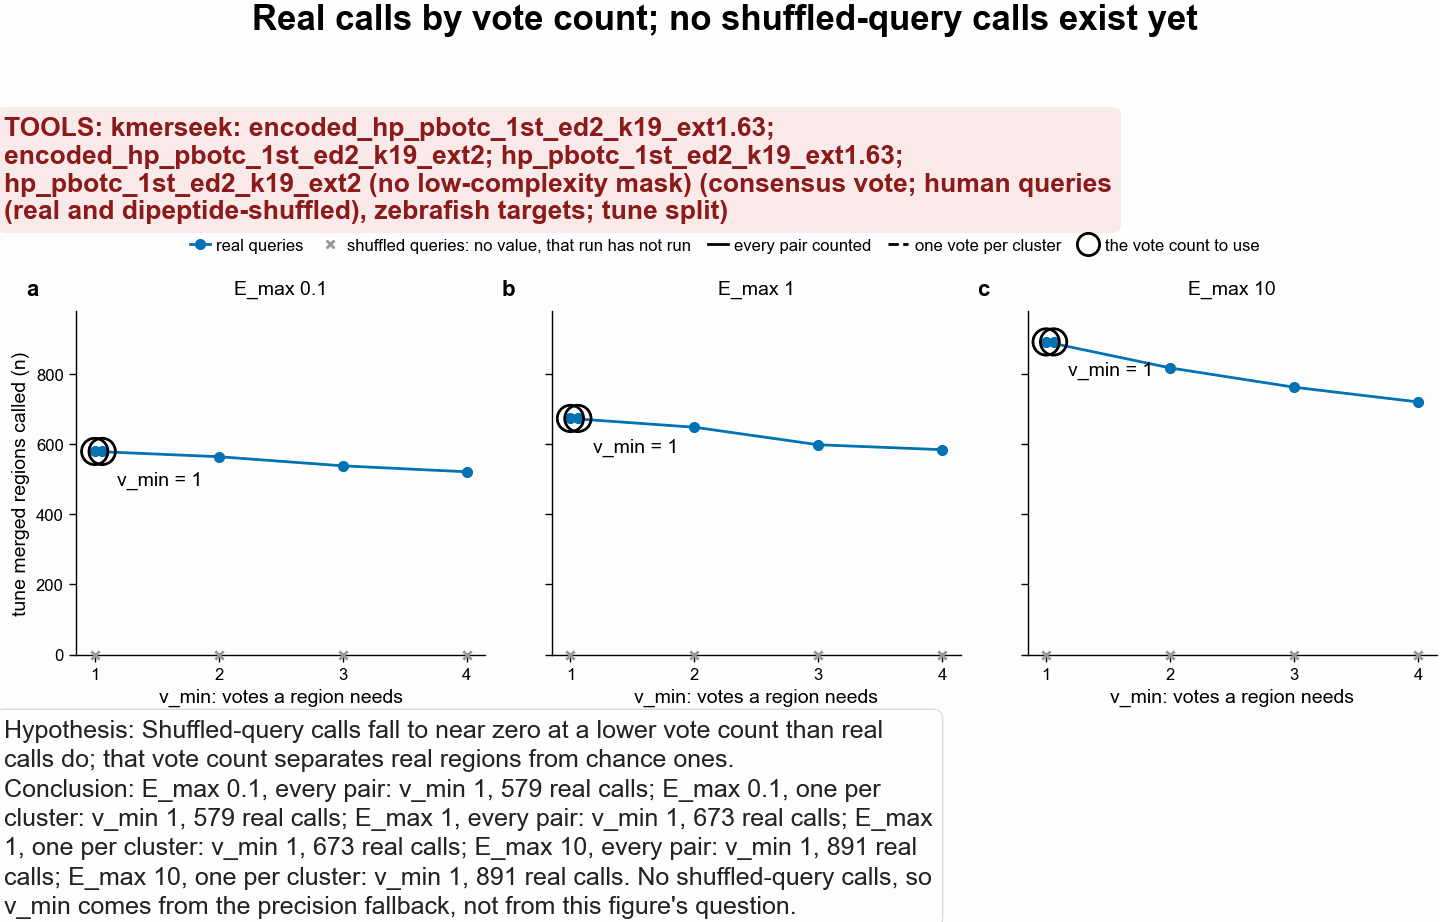

In [6]:
at = rv.vote_at_target(sw)
print(at.select("emax", "counting", "v_min", "n_called", "n_decoy_called",
                "precision_swissprot", "precision_pfam", "rule"))
for r in at.to_dicts():
    print(f"E_max {r['emax']:g}, {r['counting']}: the vote count to use is v_min = {r['v_min']} "
          f"({r['n_called']:_} tune calls; rule: {r['rule']})")
no_decoy = sw["n_decoy_called"].null_count() == sw.height
REAL_C, FAKE_C = pf.OKABE_ITO["blue"], pf.OKABE_ITO["vermillion"]
COUNT_LS = {"every pair": "-", "one per cluster": "--"}
fig, axes = pf.figure(pf.TWO_COLUMN_MM, 62, ncols=3, sharey=True)
for ax, e, letter in zip(axes, rv.EMAX_GRID, "abc"):
    for counting, ls in COUNT_LS.items():
        p = sw.filter((pl.col("emax") == e) & (pl.col("counting") == counting)).sort("v_min")
        off = 0.06 if counting == "one per cluster" else 0.0
        ax.plot(p["v_min"] + off, p["n_called"], color=REAL_C, ls=ls, marker="o")
        if not no_decoy:
            ax.plot(p["v_min"] + off, p["n_decoy_called"], color=FAKE_C, ls=ls, marker="s", mfc="white")
        hit = at.filter((pl.col("emax") == e) & (pl.col("counting") == counting))
        if hit.height:
            h = hit.row(0, named=True)
            ax.scatter([h["v_min"] + off], [h["n_called"]], s=90, facecolors="none", edgecolors="black", lw=1, zorder=4)
    if no_decoy:
        xs = sorted(sw.filter(pl.col("emax") == e)["v_min"].unique().to_list())
        ax.scatter(xs, [0] * len(xs), marker="x", color=pf.GREY, clip_on=False, zorder=4)
    h = at.filter((pl.col("emax") == e) & (pl.col("counting") == "every pair")).row(0, named=True)
    ax.annotate(f"v_min = {h['v_min']}", (h["v_min"], h["n_called"]), xytext=(8, -12), textcoords="offset points")
    ax.set_xticks(range(1, len(ARMS) + 1))
    ax.set_xlabel("v_min: votes a region needs")
    ax.set_title(f"E_max {e:g}")
    ax.set_ylim(bottom=0)
    pf.panel_label(ax, letter)
axes[0].set_ylim(0, sw["n_called"].max() * 1.1)
axes[0].set_ylabel("tune merged regions called (n)")
handles = [Line2D([], [], color=REAL_C, marker="o"),
           (Line2D([], [], ls="none", marker="x", color=pf.GREY) if no_decoy else
            Line2D([], [], color=FAKE_C, marker="s", mfc="white")),
           Line2D([], [], color="black", ls="-"), Line2D([], [], color="black", ls="--"),
           Line2D([], [], ls="none", marker="o", mfc="none", mec="black", ms=8)]
labels = ["real queries",
          "shuffled queries: no value, that run has not run" if no_decoy else "shuffled queries",
          "every pair counted", "one vote per cluster", "the vote count to use"]
fig.legend(handles, labels, loc="outside upper center", ncol=5)
stem = FIG / "263_vote_real_vs_shuffled_calls_by_vmin_zebrafish_tune"
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="consensus vote; human queries (real and dipeptide-shuffled), zebrafish targets; tune split"),
    title=("Real calls by vote count; no shuffled-query calls exist yet" if no_decoy
           else "Real and shuffled calls by vote count"),
    hypothesis="Shuffled-query calls fall to near zero at a lower vote count than real calls "
               "do; that vote count separates real regions from chance ones.",
    conclusion=("; ".join(f"E_max {r['emax']:g}, {r['counting']}: v_min {r['v_min']}, {r['n_called']:_} real calls"
                          + ("" if r['n_decoy_called'] is None else f", {r['n_decoy_called']:_} shuffled")
                          for r in at.to_dicts())
                + (". No shuffled-query calls, so v_min comes from the precision fallback, not from this figure's question." if no_decoy else ".")),

)

## 4. Every pair or one vote per cluster: the frozen setting

The two ways of counting, each at the vote count section 3 chose, side by side; then the
frozen setting by the rule in the top cell.

shape: (3, 9)
┌──────┬──────────────────┬───────────────────────┬─────────────────────┬──────────────────────────┬────────────────────────────────┬─────────────────────────────────────┬───────────────────────────┬────────────────────────────────┐
│ emax ┆ v_min_every pair ┆ v_min_one per cluster ┆ n_called_every pair ┆ n_called_one per cluster ┆ precision_swissprot_every pair ┆ precision_swissprot_one per cluster ┆ precision_pfam_every pair ┆ precision_pfam_one per cluster │
│ ---  ┆ ---              ┆ ---                   ┆ ---                 ┆ ---                      ┆ ---                            ┆ ---                                 ┆ ---                       ┆ ---                            │
│ f64  ┆ i64              ┆ i64                   ┆ i64                 ┆ i64                      ┆ f64                            ┆ f64                                 ┆ f64                       ┆ f64                            │
╞══════╪══════════════════╪═══════════════════════╪═══

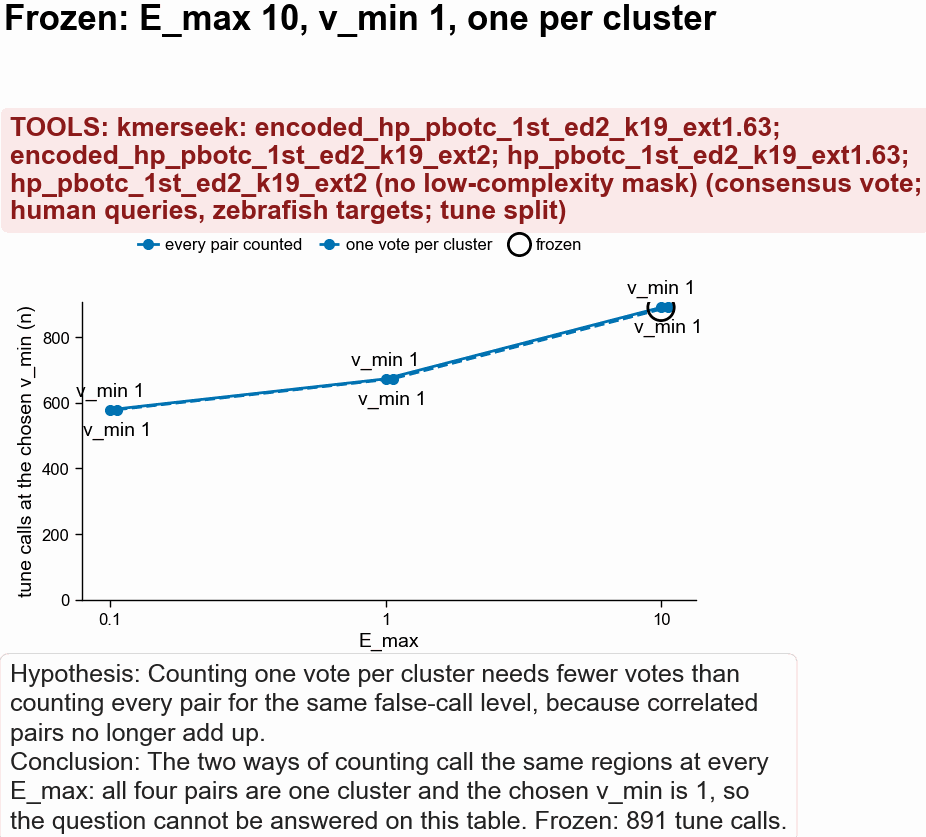

In [7]:
cmp = at.pivot(on="counting", index="emax", values=["v_min", "n_called", "precision_swissprot", "precision_pfam"])
print(cmp)
frozen = rv.freeze(at)
EMAX, VMIN, COUNTING = frozen["emax"], frozen["v_min"], frozen["counting"]
VOTE_COL = "n_cluster_votes" if COUNTING == "one per cluster" else "n_votes"
same = all(
    at.filter((pl.col("emax") == e) & (pl.col("counting") == "every pair"))["n_called"].to_list()
    == at.filter((pl.col("emax") == e) & (pl.col("counting") == "one per cluster"))["n_called"].to_list()
    for e in rv.EMAX_GRID)
print(f"\nfrozen: E_max {EMAX:g}, v_min {VMIN}, {COUNTING} "
      f"({frozen['n_clusters']} clusters of {len(ARMS)} pairs at this E_max)")
print(f"tune: {frozen['n_called']:_} calls, Swiss-Prot precision {frozen['precision_swissprot']:.3f}, "
      f"Pfam precision {frozen['precision_pfam']:.3f}")
print(f"the two ways of counting call the same regions at every E_max: {same}")
b_tune = b_rec["tune"]
print(f"combiner B on tune (nb 262): {b_tune['n_called']:_} calls, Swiss-Prot precision "
      f"{b_tune['precision_swissprot']:.3f}, Pfam precision {b_tune['precision_pfam']:.3f}")

fig, axes = pf.figure(pf.ONE_COLUMN_MM, 55, ncols=1)
ax = axes
for counting, ls in COUNT_LS.items():
    p = at.filter(pl.col("counting") == counting).sort("emax")
    off = 1.06 if counting == "one per cluster" else 1.0
    ax.plot(p["emax"] * off, p["n_called"], color=REAL_C, ls=ls, marker="o")
    for e, v, n in p.select("emax", "v_min", "n_called").iter_rows():
        ax.annotate(f"v_min {v}", (e * off, n), xytext=(0, 5 if counting == "every pair" else -9),
                    textcoords="offset points", ha="center")
ax.scatter([EMAX], [frozen["n_called"]], s=90, facecolors="none", edgecolors="black", lw=1, zorder=4)
ax.set_xscale("log")
ax.set_xticks(list(rv.EMAX_GRID), [f"{e:g}" for e in rv.EMAX_GRID])
ax.minorticks_off()
ax.set_xlabel("E_max")
ax.set_ylabel("tune calls at the chosen v_min (n)")
ax.set_ylim(bottom=0)
fig.legend([Line2D([], [], color=REAL_C, ls="-", marker="o"), Line2D([], [], color=REAL_C, ls="--", marker="o"),
            Line2D([], [], ls="none", marker="o", mfc="none", mec="black", ms=8)],
           ["every pair counted", "one vote per cluster", "frozen"], loc="outside upper center", ncol=3)
stem = FIG / "263_vote_every_pair_vs_one_per_cluster_frozen_zebrafish_tune"
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="consensus vote; human queries, zebrafish targets; tune split"),
    title=f"Frozen: E_max {EMAX:g}, v_min {VMIN}, {COUNTING}",
    hypothesis="Counting one vote per cluster needs fewer votes than counting every pair for "
               "the same false-call level, because correlated pairs no longer add up.",
    conclusion=(("The two ways of counting call the same regions at every E_max: all four pairs are one "
                 "cluster and the chosen v_min is 1, so the question cannot be answered on this table."
                 if same else "The two ways of counting differ; see the table above.")
                + f" Frozen: {frozen['n_called']:_} tune calls."),

)

## 5. The frozen setting on test

Combiner C at the frozen setting, beside combiner B at notebook 262's frozen corrected
E-value, combiner A's frozen panel from notebook 261, and notebook 262's best single pair
at its own tune threshold. Filled marks are test (reported), open marks tune. Nothing here
was chosen on test.

In [8]:
PANEL_A, EMAX_A = panel_a["panel"], panel_a["emax"]
THR_B, SINGLE, THR_SINGLE = b_rec["threshold"], b_rec["single_pair"], b_rec["single_pair_threshold"]
ONE = tried.with_columns(n_arms_tried=pl.lit(1, pl.UInt32))
single_scores = rb.attach_truth(rb.region_scores(calls.filter(pl.col("arm") == SINGLE), ONE), table)
METHOD_C = {"C": pf.OKABE_ITO["blue"], "B": pf.OKABE_ITO["bluish_green"],
            "A": pf.OKABE_ITO["reddish_purple"], "single": pf.OKABE_ITO["orange"], "phmmer": pf.GREY}
NAMES = {"C": f"combiner C, vote: v_min {VMIN}, E_max {EMAX:g}, {COUNTING}",
         "B": f"combiner B, best of {len(ARMS)}: corrected E <= {THR_B:.3g}",
         "A": f"combiner A, {len(PANEL_A)} pairs, E < {EMAX_A:g}",
         "single": f"single pair {SINGLE}, E <= {THR_SINGLE:.3g}"}
rows = []
for split, nf in (("tune", nf_tune), ("test", nf_test)):
    c = region_calls(split, nf)
    pa_s = per_arm.join(scores.filter(pl.col("split") == split).select(rv.KEY), on=rv.KEY)
    cv = rv.with_votes(c, rv.votes(pa_s, EMAX, CLUSTERS[EMAX]))
    rows.append(dict(split=split, method="C", **rb.at_threshold(cv, VOTE_COL, False, VMIN)))
    rows.append(dict(split=split, method="B", **rb.at_threshold(c, rb.RANK_SCORE, True, THR_B)))
    a = rc.Scorer(table, truth_pairs, truth, split).score(PANEL_A, EMAX_A)
    rows.append(dict(split=split, method="A", threshold=EMAX_A,
                     **{k: a[k] for k in a if k.startswith(("n_called", "precision_", "n_found_", "recall_"))}))
    s = rb.kmerseek_calls(single_scores.filter(pl.col("split") == split), truth_pairs, nf)
    rows.append(dict(split=split, method="single", **rb.at_threshold(s, "evalue_min", True, THR_SINGLE)))
report = pl.DataFrame(rows, infer_schema_length=None).select(
    "split", "method", "n_called", "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam",
    "n_called_on_swissprot_queries", "n_found_swissprot", "n_called_on_pfam_queries", "n_found_pfam")
print("\n".join(f"  {k}: {v}" for k, v in NAMES.items()))
print(report)
assert report.filter((pl.col("split") == "test") & (pl.col("method") == "B"))["n_called"][0] == b_rec["test"]["n_called"], \
    "combiner B recomputed here differs from notebook 262's yaml"

  C: combiner C, vote: v_min 1, E_max 10, one per cluster
  B: combiner B, best of 4: corrected E <= 39.9
  A: combiner A, 2 pairs, E < 10
  single: single pair encoded_hp_pbotc_1st_ed2_k19_ext2, E <= 9.97
shape: (8, 11)
┌───────┬────────┬──────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬───────────────────────────────┬───────────────────┬──────────────────────────┬──────────────┐
│ split ┆ method ┆ n_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ n_called_on_swissprot_queries ┆ n_found_swissprot ┆ n_called_on_pfam_queries ┆ n_found_pfam │
│ ---   ┆ ---    ┆ ---      ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---                           ┆ ---               ┆ ---                      ┆ ---          │
│ str   ┆ str    ┆ i64      ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ i64                           ┆ i64               ┆ i64                      ┆ i64       

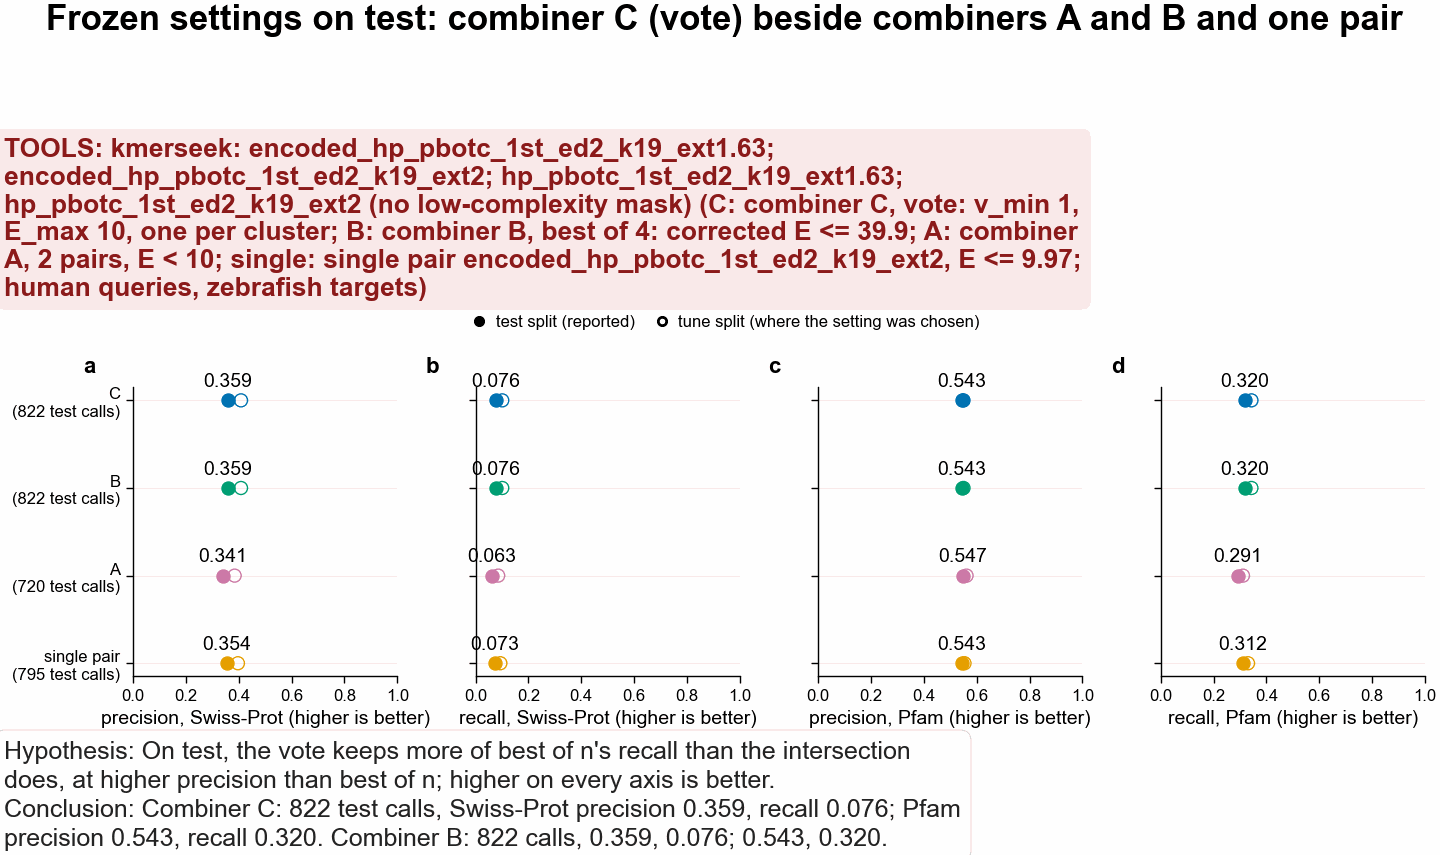

In [9]:
rep_test = report.filter(pl.col("split") == "test")
ORDER = ["C", "B", "A", "single"]
cols = [("precision_swissprot", "precision, Swiss-Prot"), ("recall_swissprot", "recall, Swiss-Prot"),
        ("precision_pfam", "precision, Pfam"), ("recall_pfam", "recall, Pfam")]
fig, axes = pf.figure(pf.TWO_COLUMN_MM, 55, ncols=4, sharey=True)
y = np.arange(len(ORDER))
for ax, (c, name), letter in zip(axes, cols, "abcd"):
    for yi, m in zip(y, ORDER):
        v_test = rep_test.filter(pl.col("method") == m)[c][0]
        v_tune = report.filter((pl.col("split") == "tune") & (pl.col("method") == m))[c][0]
        ax.scatter([v_tune], [yi], s=22, facecolors="none", edgecolors=METHOD_C[m])
        ax.scatter([v_test], [yi], s=22, color=METHOD_C[m])
        ax.annotate(f"{v_test:.3f}", (v_test, yi), xytext=(0, 5), textcoords="offset points", ha="center")
    ax.set_xlabel(name + " (higher is better)")
    ax.set_xlim(0, 1)
    ax.set_yticks(y, [f"{m if m != 'single' else 'single pair'}\n({rep_test.filter(pl.col('method') == m)['n_called'][0]:_} test calls)" for m in ORDER])
    for yi in y:
        ax.axhline(yi, color="#DDDDDD", lw=0.3, zorder=0)
    pf.panel_label(ax, letter)
axes[0].invert_yaxis()
fig.legend([Line2D([], [], ls="none", marker="o", color="black"), Line2D([], [], ls="none", marker="o", mfc="none", mec="black")],
           ["test split (reported)", "tune split (where the setting was chosen)"], loc="outside upper center", ncol=2)
stem = FIG / "263_vote_frozen_test_vs_combiner_a_b_single_pair_zebrafish"
cr = rep_test.filter(pl.col("method") == "C").row(0, named=True)
br = rep_test.filter(pl.col("method") == "B").row(0, named=True)
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=ARMS, lc=False, note="; ".join(f"{k}: {v}" for k, v in NAMES.items()) + "; human queries, zebrafish targets"),
    title=f"Frozen settings on test: combiner C (vote) beside combiners A and B and one pair",
    hypothesis="On test, the vote keeps more of best of n's recall than the intersection does, "
               "at higher precision than best of n; higher on every axis is better.",
    conclusion=(f"Combiner C: {cr['n_called']:_} test calls, Swiss-Prot precision {cr['precision_swissprot']:.3f}, "
                f"recall {cr['recall_swissprot']:.3f}; Pfam precision {cr['precision_pfam']:.3f}, recall {cr['recall_pfam']:.3f}. "
                f"Combiner B: {br['n_called']:_} calls, {br['precision_swissprot']:.3f}, {br['recall_swissprot']:.3f}; "
                f"{br['precision_pfam']:.3f}, {br['recall_pfam']:.3f}."),

)

## Saving the frozen setting

`263_consensus_vote.yaml` holds E_max, v_min, the way of counting, the clusters, the rule
that chose them, the tune and test numbers, the shuffled-query counts (null until that run
exists) and the input table's checksum.

In [10]:
def clean(d: dict) -> dict:
    return {k: (None if isinstance(v, float) and v != v else
                float(v) if isinstance(v, np.floating) else int(v) if isinstance(v, np.integer) else v)
            for k, v in d.items()}

record = {
    "combiner": "C, consensus vote: n_votes = pairs calling the merged region at region_evalue < emax; "
                "called when n_votes >= v_min; ranked by n_votes, ties by the corrected best-of-n E-value",
    "emax": EMAX,
    "v_min": VMIN,
    "counting": COUNTING,
    "clusters": {a: int(c) for a, c in CLUSTERS[EMAX].items()},
    "cluster_rule": f"complete linkage on 1 - agreement, every two pairs in a cluster agree > {rv.AGREE_MIN}; "
                    "agreement = merged regions both call / merged regions either calls, tune split",
    "selection": "tune split; per (emax, counting) the smallest v_min with shuffled-query calls <= "
                 f"{rv.DECOY_SHARE_MAX} x real calls, or without shuffled queries tune Swiss-Prot "
                 f"precision >= {rv.TARGET_PRECISION} (Pfam when no setting reaches it on Swiss-Prot); "
                 "then the most tune calls, ties to one vote per cluster, then the smaller emax",
    "rule_used": frozen["rule"],
    "pairs": ARMS,
    "tune": clean({k: v for k, v in report.filter((pl.col("split") == "tune") & (pl.col("method") == "C")).row(0, named=True).items() if k not in ("split", "method")}),
    "test": clean({k: v for k, v in report.filter((pl.col("split") == "test") & (pl.col("method") == "C")).row(0, named=True).items() if k not in ("split", "method")}),
    "tune_sweep_at_target": [clean(r) for r in at.to_dicts()],
    "input_table": str(TABLE),
    "input_table_sha256": sha256(TABLE),
    "input_note": f"{len(ARMS)} pairs, species {SPECIES}; shuffled-query files "
                  f"{'present' if decoy_per_arm is not None else 'absent'}",
    "notebook": "notebooks/263_combiner_c_consensus_vote.ipynb",
    "written": date.today().isoformat(),
}
OUT_YAML.write_text(yaml.safe_dump(record, sort_keys=False, width=100))
print(OUT_YAML.read_text())

combiner: 'C, consensus vote: n_votes = pairs calling the merged region at region_evalue < emax; called
  when n_votes >= v_min; ranked by n_votes, ties by the corrected best-of-n E-value'
emax: 10.0
v_min: 1
counting: one per cluster
clusters:
  encoded_hp_pbotc_1st_ed2_k19_ext1.63: 0
  encoded_hp_pbotc_1st_ed2_k19_ext2: 0
  hp_pbotc_1st_ed2_k19_ext1.63: 0
  hp_pbotc_1st_ed2_k19_ext2: 0
cluster_rule: complete linkage on 1 - agreement, every two pairs in a cluster agree > 0.8; agreement =
  merged regions both call / merged regions either calls, tune split
selection: tune split; per (emax, counting) the smallest v_min with shuffled-query calls <= 0.05 x real
  calls, or without shuffled queries tune Swiss-Prot precision >= 0.5 (Pfam when no setting reaches it
  on Swiss-Prot); then the most tune calls, ties to one vote per cluster, then the smaller emax
rule_used: tune pfam precision >= 0.5 (no shuffled-query calls)
pairs:
- encoded_hp_pbotc_1st_ed2_k19_ext1.63
- encoded_hp_pbotc_1st_e

## 6. Multi-domain queries: how many domains each method lands

The same question and figure as notebooks 261 and 262: for test queries with at least two
Pfam domains, how many of those domains each method lands in, per query and target
species. A domain is landed when at least half of one call lies inside it.

- Combiner C, B and A, and the single pair, at their frozen settings (section 5).
- phmmer: each per-domain hit's query span at i-Evalue < 10, the cut notebook 260 put on
  kmerseek's E-value.

The kmerseek rows use merged-region extents, which grow when calls chain across domain
borders; phmmer's hits are not merged. A merged region that spans two domains lands in
neither.

In [11]:
pf_dom = (truth.filter(pl.col("truth_set") == "pfam").unique(subset=rc.FEATURE_KEY)
          .with_columns(split=rt.query_split(pl.col("accession"))))
multi = (pf_dom.filter(pl.col("split") == "test").group_by("accession").agg(n_domains=pl.len())
         .filter(pl.col("n_domains") >= 2))
grid = multi.join(pl.DataFrame({"species": SPECIES}), how="cross")
print(f"test queries with >= 2 Pfam domains: {multi.height}; domains on them: {multi['n_domains'].sum():_}")

c_test = region_calls("test", nf_test)
pa_test = per_arm.join(scores.filter(pl.col("split") == "test").select(rv.KEY), on=rv.KEY)
cv_test = rv.with_votes(c_test, rv.votes(pa_test, EMAX, CLUSTERS[EMAX]))
def spans_of(r: pl.DataFrame) -> pl.DataFrame:
    return r.select("accession", "species", start="merged_start", end="merged_end")
scorer_a = rc.Scorer(table, truth_pairs, truth, "test")
a_spans = (scorer_a.regions.filter(pl.col("rid").is_in(scorer_a.called(PANEL_A, EMAX_A)))
           .join(scorer_a.t.unique(subset=rc.KEY).select(rc.KEY + ["merged_start", "merged_end"]), on=rc.KEY)
           .select("accession", "species", start="merged_start", end="merged_end"))
s_test = single_scores.filter((pl.col("split") == "test") & (pl.col("evalue_min") <= THR_SINGLE))
phm = pl.concat([rc.load_phmmer(PHMMER_DIR / f"human_vs_{sp}.hmmer3_phmmer.tsv.gz", sp) for sp in SPECIES])
phm = phm.filter(pl.col("evalue") < rt.EVALUE_MAX).select("accession", "species", start="qstart", end="qend")
spans = {"C": spans_of(cv_test.regions.filter(pl.col(VOTE_COL) >= VMIN)),
         "B": spans_of(c_test.regions.filter(pl.col(rb.RANK_SCORE) <= THR_B)),
         "A": a_spans, "single": spans_of(s_test), "phmmer": phm}
dom_in = pf_dom.filter(pl.col("accession").is_in(multi["accession"].implode()))
counts = grid
for name, s in spans.items():
    c = rc.domains_landed(s.filter(pl.col("accession").is_in(multi["accession"].implode())), dom_in, "start", "end")
    counts = counts.join(c.rename({"n_landed": name}), on=["accession", "species"], how="left")
MD = list(spans)
counts = counts.with_columns(pl.col(n).fill_null(0) for n in MD)
dist = (counts.unpivot(index=["accession", "species", "n_domains"], on=MD, variable_name="method", value_name="n_landed")
        .group_by("method", "n_landed").len("n_queries").sort("method", "n_landed"))
print(dist.pivot(on="method", index="n_landed", values="n_queries").fill_null(0).sort("n_landed"))
print(counts.select(*[pl.col(n).mean().round(3).alias(f"mean | {n}") for n in MD],
                    *[(pl.col(n) == 0).sum().alias(f"zero landed | {n}") for n in MD]).unpivot())
mcmp = counts.select(vote_more_than_phmmer=(pl.col("C") > pl.col("phmmer")).sum(),
                     same_as_phmmer=(pl.col("C") == pl.col("phmmer")).sum(),
                     phmmer_more=(pl.col("C") < pl.col("phmmer")).sum(),
                     vote_more_than_b=(pl.col("C") > pl.col("B")).sum(),
                     b_more_than_vote=(pl.col("C") < pl.col("B")).sum(),
                     vote_more_than_a=(pl.col("C") > pl.col("A")).sum())
print(mcmp)
print(counts.join(queries, on="accession").sort("n_domains", descending=True).head(12))

test queries with >= 2 Pfam domains: 241; domains on them: 939
shape: (14, 6)
┌──────────┬─────┬─────┬─────┬────────┬────────┐
│ n_landed ┆ A   ┆ B   ┆ C   ┆ phmmer ┆ single │
│ ---      ┆ --- ┆ --- ┆ --- ┆ ---    ┆ ---    │
│ u32      ┆ u32 ┆ u32 ┆ u32 ┆ u32    ┆ u32    │
╞══════════╪═════╪═════╪═════╪════════╪════════╡
│ 0        ┆ 114 ┆ 98  ┆ 98  ┆ 18     ┆ 102    │
│ 1        ┆ 96  ┆ 105 ┆ 105 ┆ 52     ┆ 103    │
│ 2        ┆ 27  ┆ 33  ┆ 33  ┆ 82     ┆ 31     │
│ 3        ┆ 3   ┆ 4   ┆ 4   ┆ 32     ┆ 4      │
│ 4        ┆ 0   ┆ 0   ┆ 0   ┆ 25     ┆ 0      │
│ 5        ┆ 0   ┆ 0   ┆ 0   ┆ 12     ┆ 0      │
│ 6        ┆ 1   ┆ 1   ┆ 1   ┆ 5      ┆ 1      │
│ 7        ┆ 0   ┆ 0   ┆ 0   ┆ 3      ┆ 0      │
│ 8        ┆ 0   ┆ 0   ┆ 0   ┆ 3      ┆ 0      │
│ 9        ┆ 0   ┆ 0   ┆ 0   ┆ 3      ┆ 0      │
│ 10       ┆ 0   ┆ 0   ┆ 0   ┆ 2      ┆ 0      │
│ 11       ┆ 0   ┆ 0   ┆ 0   ┆ 1      ┆ 0      │
│ 14       ┆ 0   ┆ 0   ┆ 0   ┆ 1      ┆ 0      │
│ 17       ┆ 0   ┆ 0   ┆ 0   ┆ 2      ┆ 

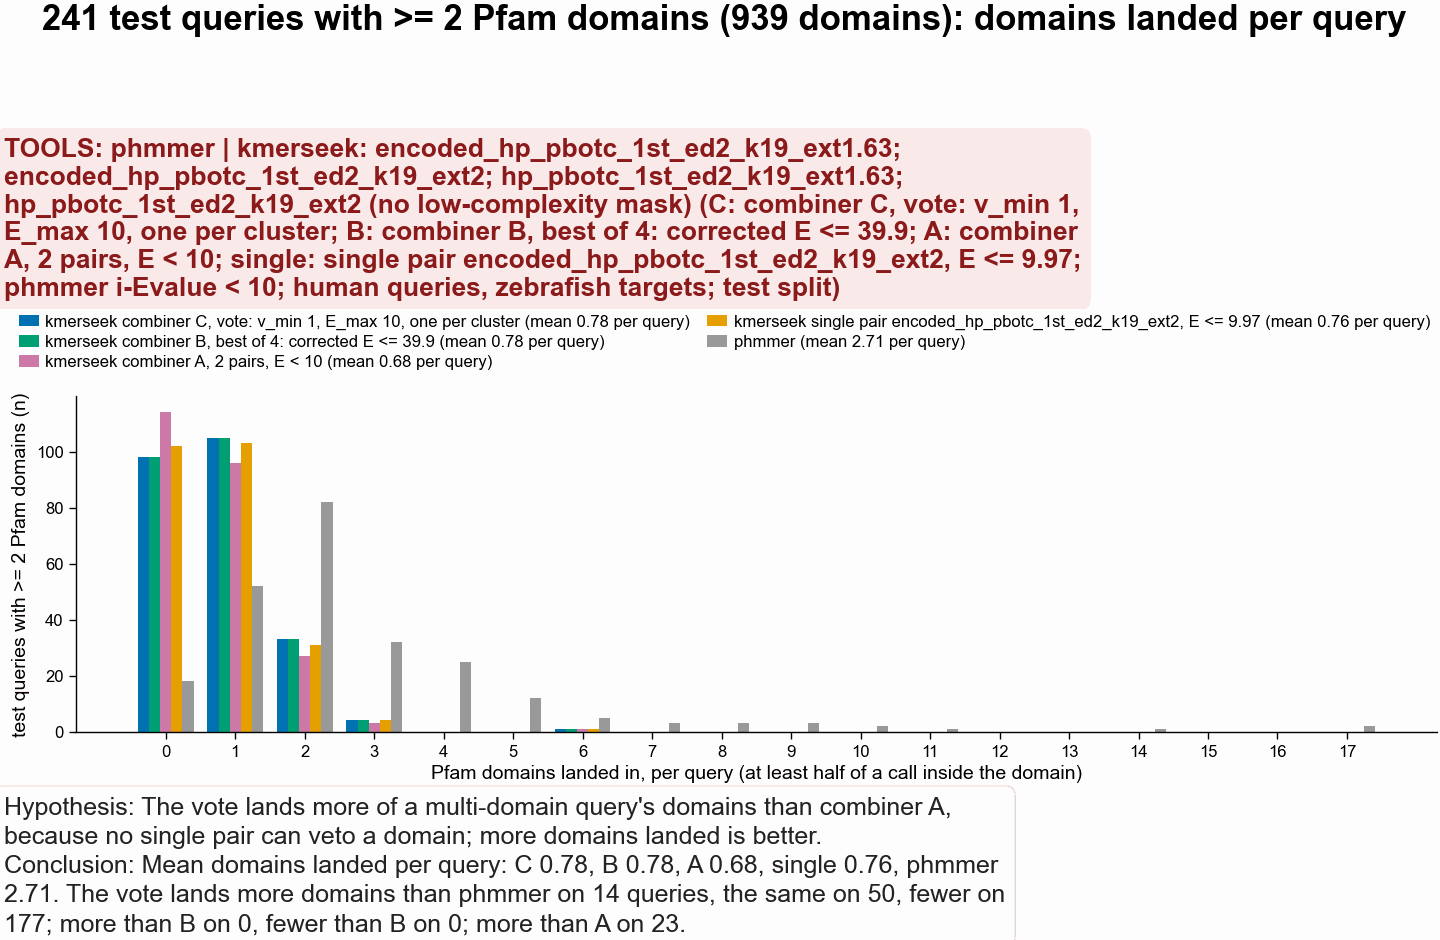

In [12]:
xs = np.arange(0, int(dist["n_landed"].max()) + 1)
w = 0.8 / len(MD)
fig, ax = pf.figure(pf.TWO_COLUMN_MM, 62)
for i, m in enumerate(MD):
    d = dict(dist.filter(pl.col("method") == m).select("n_landed", "n_queries").iter_rows())
    ys = [d.get(int(x), 0) for x in xs]
    off = (i - (len(MD) - 1) / 2) * w
    lab = "phmmer" if m == "phmmer" else "kmerseek " + NAMES[m]
    ax.bar(xs + off, ys, width=w, color=METHOD_C[m], label=f"{lab} (mean {counts[m].mean():.2f} per query)")
ax.set_xticks(xs)
ax.set_xlabel("Pfam domains landed in, per query (at least half of a call inside the domain)")
ax.set_ylabel("test queries with >= 2 Pfam domains (n)")
fig.legend(loc="outside upper center", ncol=2)
stem = FIG / "263_multidomain_domains_landed_vote_vs_combiners_phmmer_zebrafish_test"
mc = mcmp.row(0, named=True)
notebook_figure(
    fig, stem,
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=ARMS, lc=False,
                        note="; ".join(f"{k}: {v}" for k, v in NAMES.items()) + "; phmmer i-Evalue < 10; human queries, zebrafish targets; test split"),
    title=f"{multi.height} test queries with >= 2 Pfam domains ({multi['n_domains'].sum():_} domains): domains landed per query",
    hypothesis="The vote lands more of a multi-domain query's domains than combiner A, because "
               "no single pair can veto a domain; more domains landed is better.",
    conclusion=("Mean domains landed per query: " + ", ".join(f"{m} {counts[m].mean():.2f}" for m in MD)
                + f". The vote lands more domains than phmmer on {mc['vote_more_than_phmmer']} queries, the same on "
                f"{mc['same_as_phmmer']}, fewer on {mc['phmmer_more']}; more than B on {mc['vote_more_than_b']}, "
                f"fewer than B on {mc['b_more_than_vote']}; more than A on {mc['vote_more_than_a']}."),

)

## 7. Known cases: where Ced9-BCL2, P66-CD47 and BHF fall in the vote ranking

Notebook 241's search: Ced9, P66 and BHF (queries) against 19_732 GENCODE v49 canonical
human proteins (the target database), 152 alphabet-ksize pairs. Calls at E < E_max are
merged per query and target protein with notebook 260's merge, so a merged region here is
one stretch of the query against one human protein. Votes and the one-per-cluster count
are computed the same way, with clusters from this search's own calls (agreement > 0.8).
Every merged region of one query is ranked by votes, then by corrected E-value
(152 pairs searched x lowest E-value). Rank 1 is the best; ties share the best rank.

The cases:
- Ced9 against BCL2, at the BH1 motif: UniProt P41958 160-179 on Ced9 (BH1, motif feature),
  P10415 136-155 on BCL2. The Ced9 in notebook 241's query file is identical to P41958.
- P66 against CD47: P66 181-187 (QENDKDT; mature numbering, which is the numbering of
  notebook 241's P66 sequence, = UniProt 202-208) and CD47 UniProt 115-124 (mature 97-106),
  the span holding 8 of CD47's P66 contacts ([notebook 245](https://github.com/seanome/2024-kmerseek-analysis/pull/96)).
- BHF: the regions PR #44 tested for landing on human Pfam domains
  (`BHF.hp_lehninger2.k24.scaled1.lcremoved.lambda-region.query_subset.csv`, a
  kmerseek build from the `olgabot/ka-lambda-per-region` branch), matched to notebook 241's
  merged regions on the same human protein that overlap the PR #44 span on BHF.

A case is ranked when a merged region on its target overlaps its query span. E_max is read
at the grid {0.1, 1, 10} and, outside the grid, at 100_000, only to see whether a vote
would move these pairs if they were let in at all.

In [13]:
CASE_DIR = Path.home() / "data" / "botryllus" / "alphabet-ranking-three-cases"
CASE_REGIONS = CASE_DIR / "regions.parquet"
GENCODE = Path.home() / "data" / "gencode" / "human" / "v49" / "gencode.v49.pc_translations.canonical.fa"
PR44_BHF = Path.home() / "data" / "botryllus" / "kmerseek-lambda-region" / "BHF.hp_lehninger2.k24.scaled1.lcremoved.lambda-region.query_subset.csv"
UNIPROT = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "263_consensus_vote" / "uniprot_cache"
LOOSE = 100_000.0
CASE_EMAX = list(rv.EMAX_GRID) + [LOOSE]

def read_fasta(path: Path) -> dict[str, str]:
    out, name = {}, None
    for line in path.read_text().splitlines():
        if line.startswith(">"):
            name = line[1:].split()[0]
            out[name] = []
        elif name:
            out[name].append(line.strip())
    return {k: "".join(v) for k, v in out.items()}

def uniprot_motif(acc: str, desc: str) -> tuple[int, int, str]:
    # Fetched once from rest.uniprot.org/uniprotkb/<acc>.json and cached; read from the cache.
    d = json.loads((UNIPROT / f"{acc}.json").read_text())
    f = next(f for f in d["features"] if f.get("description") == desc)
    return f["location"]["start"]["value"], f["location"]["end"]["value"], d["sequence"]["value"]

qseq = read_fasta(CASE_DIR / "queries.fa")
human = read_fasta(GENCODE)
arms_csv = pl.read_csv(CASE_DIR / "arms.csv")
N_TRIED = int(arms_csv.filter(pl.col("searched")).height)
ced9_bh1 = uniprot_motif("P41958", "BH1")
bcl2_bh1 = uniprot_motif("P10415", "BH1")
assert ced9_bh1[2] == qseq["Ced9"], "Ced9 in notebook 241 is not UniProt P41958"
gene_of = {h: h.split("|")[6] for h in human}
bcl2_h = [h for h, g in gene_of.items() if g == "BCL2"]
cd47_h = [h for h, g in gene_of.items() if g == "CD47"]
assert human[bcl2_h[0]] == bcl2_bh1[2], "GENCODE BCL2 differs from UniProt P10415"
p66_loop = qseq["P66"].find("QENDKDT") + 1
print(f"pairs searched by notebook 241 (n_tried): {N_TRIED}; human proteins: {len(human):_}")
print(f"Ced9 BH1 {ced9_bh1[:2]}: {qseq['Ced9'][ced9_bh1[0]-1:ced9_bh1[1]]}; BCL2 BH1 {bcl2_bh1[:2]}: {human[bcl2_h[0]][bcl2_bh1[0]-1:bcl2_bh1[1]]}")
print(f"P66 loop at {p66_loop}-{p66_loop + 6}: {qseq['P66'][p66_loop-1:p66_loop+6]}; CD47 115-124: {human[cd47_h[0]][114:124]} (length {len(human[cd47_h[0]])})")

CASES = [dict(case="Ced9 - BCL2, BH1", query="Ced9", target=bcl2_h[0], qs=ced9_bh1[0], qe=ced9_bh1[1], ts=bcl2_bh1[0], te=bcl2_bh1[1]),
         dict(case="P66 - CD47, loop / contacts", query="P66", target=cd47_h[0], qs=p66_loop, qe=p66_loop + 6, ts=115, te=124)]
pr44 = (pl.read_csv(PR44_BHF).select("target_name", "region_start", "region_end", "region_evalue")
        .unique().sort("region_evalue", "target_name", "region_start"))
for r in pr44.iter_rows(named=True):
    CASES.append(dict(case=f"BHF - {gene_of.get(r['target_name'], r['target_name'][:12])}, PR #44 {r['region_start'] + 1}-{r['region_end']}",
                      query="BHF", target=r["target_name"], qs=r["region_start"] + 1, qe=r["region_end"], ts=None, te=None,
                      pr44_evalue=r["region_evalue"]))
print(f"PR #44 BHF regions: {pr44.height} (distinct target and span); targets found in GENCODE v49 canonical: "
      f"{sum(t in human for t in pr44['target_name'])}")

pairs searched by notebook 241 (n_tried): 152; human proteins: 19_732
Ced9 BH1 (160, 179): QTDQCPMSYGRLIGLISFGG; BCL2 BH1 (136, 155): ELFRDGVNWGRIVAFFEFGG
P66 loop at 181-187: QENDKDT; CD47 115-124: EVTELTREGE (length 323)
PR #44 BHF regions: 66 (distinct target and span); targets found in GENCODE v49 canonical: 66


In [14]:
case_calls = rv.case_calls(CASE_REGIONS, LOOSE)
print(f"notebook 241 calls with E < {LOOSE:_.0f}: {case_calls.height:_}; per query:")
print(case_calls.group_by("accession").agg(calls=pl.len(), pairs=pl.col("arm").n_unique(),
                                           targets=pl.col("species").n_unique()).sort("accession"))
CASE_ARMS = sorted(case_calls["arm"].unique().to_list())
ranked, CASE_CLUSTERS, CASE_AGREE = {}, {}, {}
for e in CASE_EMAX:
    m = rt.merge_calls(case_calls.filter(pl.col("region_evalue") < e))
    pa = rv.per_arm_best(m)
    arms_e = sorted(pa["arm"].unique().to_list())
    j, n = rv.agreement(pa, e, arms_e)
    cl, z = rv.clusters(j, arms_e)
    CASE_CLUSTERS[e], CASE_AGREE[e] = cl, (j, arms_e, z)
    r = rv.rank_units(pa, N_TRIED, e, cl).join(
        m.select(rv.KEY + ["merged_start", "merged_end"]).unique(), on=rv.KEY)
    ranked[e] = (r, m)
    print(f"E_max {e:g}: pairs with a call {len(arms_e)} of {N_TRIED}, clusters {len(set(cl.values()))}, "
          f"merged regions with a vote {r.filter(pl.col('counting') == 'n_votes').height:_}, "
          f"most votes {r['n_votes'].max()}, most cluster votes {r['n_cluster_votes'].max()}")

notebook 241 calls with E < 100_000: 799_134; per query:
shape: (3, 4)
┌───────────┬────────┬───────┬─────────┐
│ accession ┆ calls  ┆ pairs ┆ targets │
│ ---       ┆ ---    ┆ ---   ┆ ---     │
│ str       ┆ u32    ┆ u32   ┆ u32     │
╞═══════════╪════════╪═══════╪═════════╡
│ BHF       ┆ 153034 ┆ 61    ┆ 18023   │
│ Ced9      ┆ 213130 ┆ 63    ┆ 18806   │
│ P66       ┆ 432970 ┆ 69    ┆ 19434   │
└───────────┴────────┴───────┴─────────┘
E_max 0.1: pairs with a call 4 of 152, clusters 1, merged regions with a vote 1, most votes 4, most cluster votes 1
E_max 1: pairs with a call 17 of 152, clusters 11, merged regions with a vote 15, most votes 6, most cluster votes 2


E_max 10: pairs with a call 47 of 152, clusters 47, merged regions with a vote 393, most votes 8, most cluster votes 8


E_max 100000: pairs with a call 69 of 152, clusters 68, merged regions with a vote 279_869, most votes 33, most cluster votes 33


In [15]:
raw_case = pl.scan_parquet(CASE_REGIONS)

def locate(case: dict, e: float) -> dict:
    r, m = ranked[e]
    hit = r.filter((pl.col("accession") == case["query"]) & (pl.col("species") == case["target"])
                   & (pl.col("merged_start") <= case["qe"]) & (pl.col("merged_end") >= case["qs"]))
    out = dict(case=case["case"], emax=e)
    for col in ("n_votes", "n_cluster_votes"):
        h = hit.filter(pl.col("counting") == col).sort("rank")
        if h.height:
            b = h.row(0, named=True)
            out.update({f"rank_{col}": b["rank"], f"n_tied_{col}": b["n_tied"], f"of_{col}": b["n_ranked"],
                        f"votes_{col}": b[col], "merged": f"{b['merged_start']}-{b['merged_end']}",
                        "evalue_corrected": b["evalue_best_of_n_corrected"]})
        else:
            n_rank = r.filter((pl.col("accession") == case["query"]) & (pl.col("counting") == col)).height
            out.update({f"rank_{col}": None, f"n_tied_{col}": None, f"of_{col}": n_rank, f"votes_{col}": 0})
    return out

loc = pl.DataFrame([locate(c, e) for c in CASES for e in CASE_EMAX], infer_schema_length=None)
# The lowest E-value any of the 152 pairs gave on the case's target, overlapping its query span, any E.
best_any = []
for c in CASES:
    x = raw_case.filter((pl.col("query_name") == c["query"]) & (pl.col("target_name") == c["target"])
                        & (pl.col("region_start") < c["qe"]) & (pl.col("region_end") >= c["qs"])).collect()
    best_any.append(dict(case=c["case"], calls_any_evalue=x.height,
                         pairs_any_evalue=x.select(pl.struct("alphabet", "ksize_arm").n_unique()).item() if x.height else 0,
                         pairs_with_evalue=x.filter(pl.col("region_evalue").is_finite()).select(pl.struct("alphabet", "ksize_arm").n_unique()).item() if x.height else 0,
                         lowest_evalue=x["region_evalue"].min() if x.height else None))
best_any = pl.DataFrame(best_any)
SHOW = ["case", "emax", "votes_n_votes", "rank_n_votes", "of_n_votes", "n_tied_n_votes",
        "votes_n_cluster_votes", "rank_n_cluster_votes", "of_n_cluster_votes", "merged", "evalue_corrected"]
print("Ced9 - BCL2 and P66 - CD47:")
print(loc.filter(~pl.col("case").str.starts_with("BHF")).select(SHOW))
print(best_any.filter(~pl.col("case").str.starts_with("BHF")))
print("\nBHF regions from PR #44, at E_max 10 and at the loose 100_000:")
bhf = loc.filter(pl.col("case").str.starts_with("BHF"))
print(bhf.filter(pl.col("emax").is_in([10.0, LOOSE])).select(SHOW))
print(f"\nBHF PR #44 regions with any vote at E_max 10: {bhf.filter((pl.col('emax') == 10.0) & (pl.col('votes_n_votes') > 0)).height} of {len(CASES) - 2}; "
      f"at {LOOSE:_.0f}: {bhf.filter((pl.col('emax') == LOOSE) & (pl.col('votes_n_votes') > 0)).height}")
print(best_any.filter(pl.col("case").str.starts_with("BHF")).select(
    pl.col("lowest_evalue").min().alias("lowest E any BHF case"), (pl.col("lowest_evalue") < 10).sum().alias("cases with E < 10"),
    pl.col("calls_any_evalue").eq(0).sum().alias("cases with no call at any E")))

Ced9 - BCL2 and P66 - CD47:
shape: (8, 11)
┌─────────────────────────────┬──────────┬───────────────┬──────────────┬────────────┬────────────────┬───────────────────────┬──────────────────────┬────────────────────┬─────────┬──────────────────┐
│ case                        ┆ emax     ┆ votes_n_votes ┆ rank_n_votes ┆ of_n_votes ┆ n_tied_n_votes ┆ votes_n_cluster_votes ┆ rank_n_cluster_votes ┆ of_n_cluster_votes ┆ merged  ┆ evalue_corrected │
│ ---                         ┆ ---      ┆ ---           ┆ ---          ┆ ---        ┆ ---            ┆ ---                   ┆ ---                  ┆ ---                ┆ ---     ┆ ---              │
│ str                         ┆ f64      ┆ i64           ┆ i64          ┆ i64        ┆ i64            ┆ i64                   ┆ i64                  ┆ i64                ┆ str     ┆ f64              │
╞═════════════════════════════╪══════════╪═══════════════╪══════════════╪════════════╪════════════════╪═══════════════════════╪══════════════════════╪═══

### The real residues of the top voting pair's call

For each case, the call of the pair with the lowest E-value inside the matched merged
region at the loose E_max (the top voting pair). When no merged region matches even there,
the call with the lowest E-value on that target overlapping the span, at any E-value. Query
over target, 1-based coordinates at both ends of each line. Match line: `|` the same
residue, `+` a different residue in the same class of that pair's alphabet, a space
otherwise. Under each pair, the same stretch encoded in that alphabet (one letter per
class: a is the first class in `rv.residue_class`, b the second), with `|`
where the classes match. `class mismatches` is checked against kmerseek's own
`region_n_mismatches`.

In [16]:
def top_call(case: dict) -> tuple[dict | None, str]:
    r, m = ranked[LOOSE]
    hit = (m.filter((pl.col("accession") == case["query"]) & (pl.col("species") == case["target"])
                    & (pl.col("merged_start") <= case["qe"]) & (pl.col("merged_end") >= case["qs"])))
    if hit.height:
        return hit.sort("region_evalue", "region_start").row(0, named=True), f"top voting pair at E_max {LOOSE:_.0f}"
    x = raw_case.filter((pl.col("query_name") == case["query"]) & (pl.col("target_name") == case["target"])
                        & (pl.col("region_start") < case["qe"]) & (pl.col("region_end") >= case["qs"])).collect()
    if not x.height:
        return None, "no call by any of the 152 pairs"
    b = (x.with_columns(arm=pl.col("alphabet") + "_k" + pl.col("ksize_arm").cast(pl.String),
                        **{c: pl.col(c).cast(pl.Int64) for c in ("region_start", "region_end", "target_start", "target_end")})
         .sort("region_evalue", pl.col("region_length"), descending=[False, True]).row(0, named=True))
    return b, "lowest E-value call at any E-value (no merged region at the loose cut)"

shown = {}
for case in CASES[:2] + [c for c in CASES[2:] if any(
        loc.filter((pl.col("case") == c["case"]) & (pl.col("emax") == 10.0))["votes_n_votes"] > 0)]:
    row, why = top_call(case)
    print(f"== {case['case']}: {why}")
    if row is None:
        print()
        continue
    shown[case["case"]] = row
    tname = gene_of.get(case["target"], "target")
    print(rv.show_call(qseq[case["query"]], human[case["target"]], row, case["query"], tname))
    print()
mism = [(k, r["region_n_mismatches"], sum(rv.residue_class(r["alphabet"]).get(a) != rv.residue_class(r["alphabet"]).get(b)
         for a, b in zip(qseq[c["query"]][r["region_start"]:r["region_end"]], human[c["target"]][r["target_start"]:r["target_end"]])))
        for c in CASES for k, r in shown.items() if k == c["case"]]
print("class mismatches here vs kmerseek's region_n_mismatches:", mism)

== Ced9 - BCL2, BH1: top voting pair at E_max 100_000
hp_lehninger2_k19  E = 1.12e+04  length 26  identical 5  same class 19  class mismatches 2 (kmerseek: 2.0)
Ced9           163 QCPMSYGRLIGLISFGGFVAAKMMES 188  
                   ++++++||++++++|||++ ++ +++
BCL2           139 RDGVNWGRIVAFFEFGGVMCVESVNR 164  
Ced9 encoded       bbaabaabaaaaabaaaaaaabaabb
                   ||||||||||||||||||| || |||
BCL2 encoded       bbaabaabaaaaabaaaaababbabb

== P66 - CD47, loop / contacts: lowest E-value call at any E-value (no merged region at the loose cut)
polarity4_k9  E = inf  length 19  identical 0  same class 14  class mismatches 5 (kmerseek: 5.0)
P66            163 PKLDLTFAIGGTGTGNRNQ 181  
                   + + +++++++++ +  ++
CD47           277 ILALAQLLGLVYMKFVASN 295  
P66 encoded        adacabaaaaabababdbb
                   | | ||||||||| |  ||
CD47 encoded       aaaaabaaaaabadaaabb

== BHF - DICER1, PR #44 106-149: top voting pair at E_max 100_000
hp_lehninger2_k24  E = 2.96  length 4

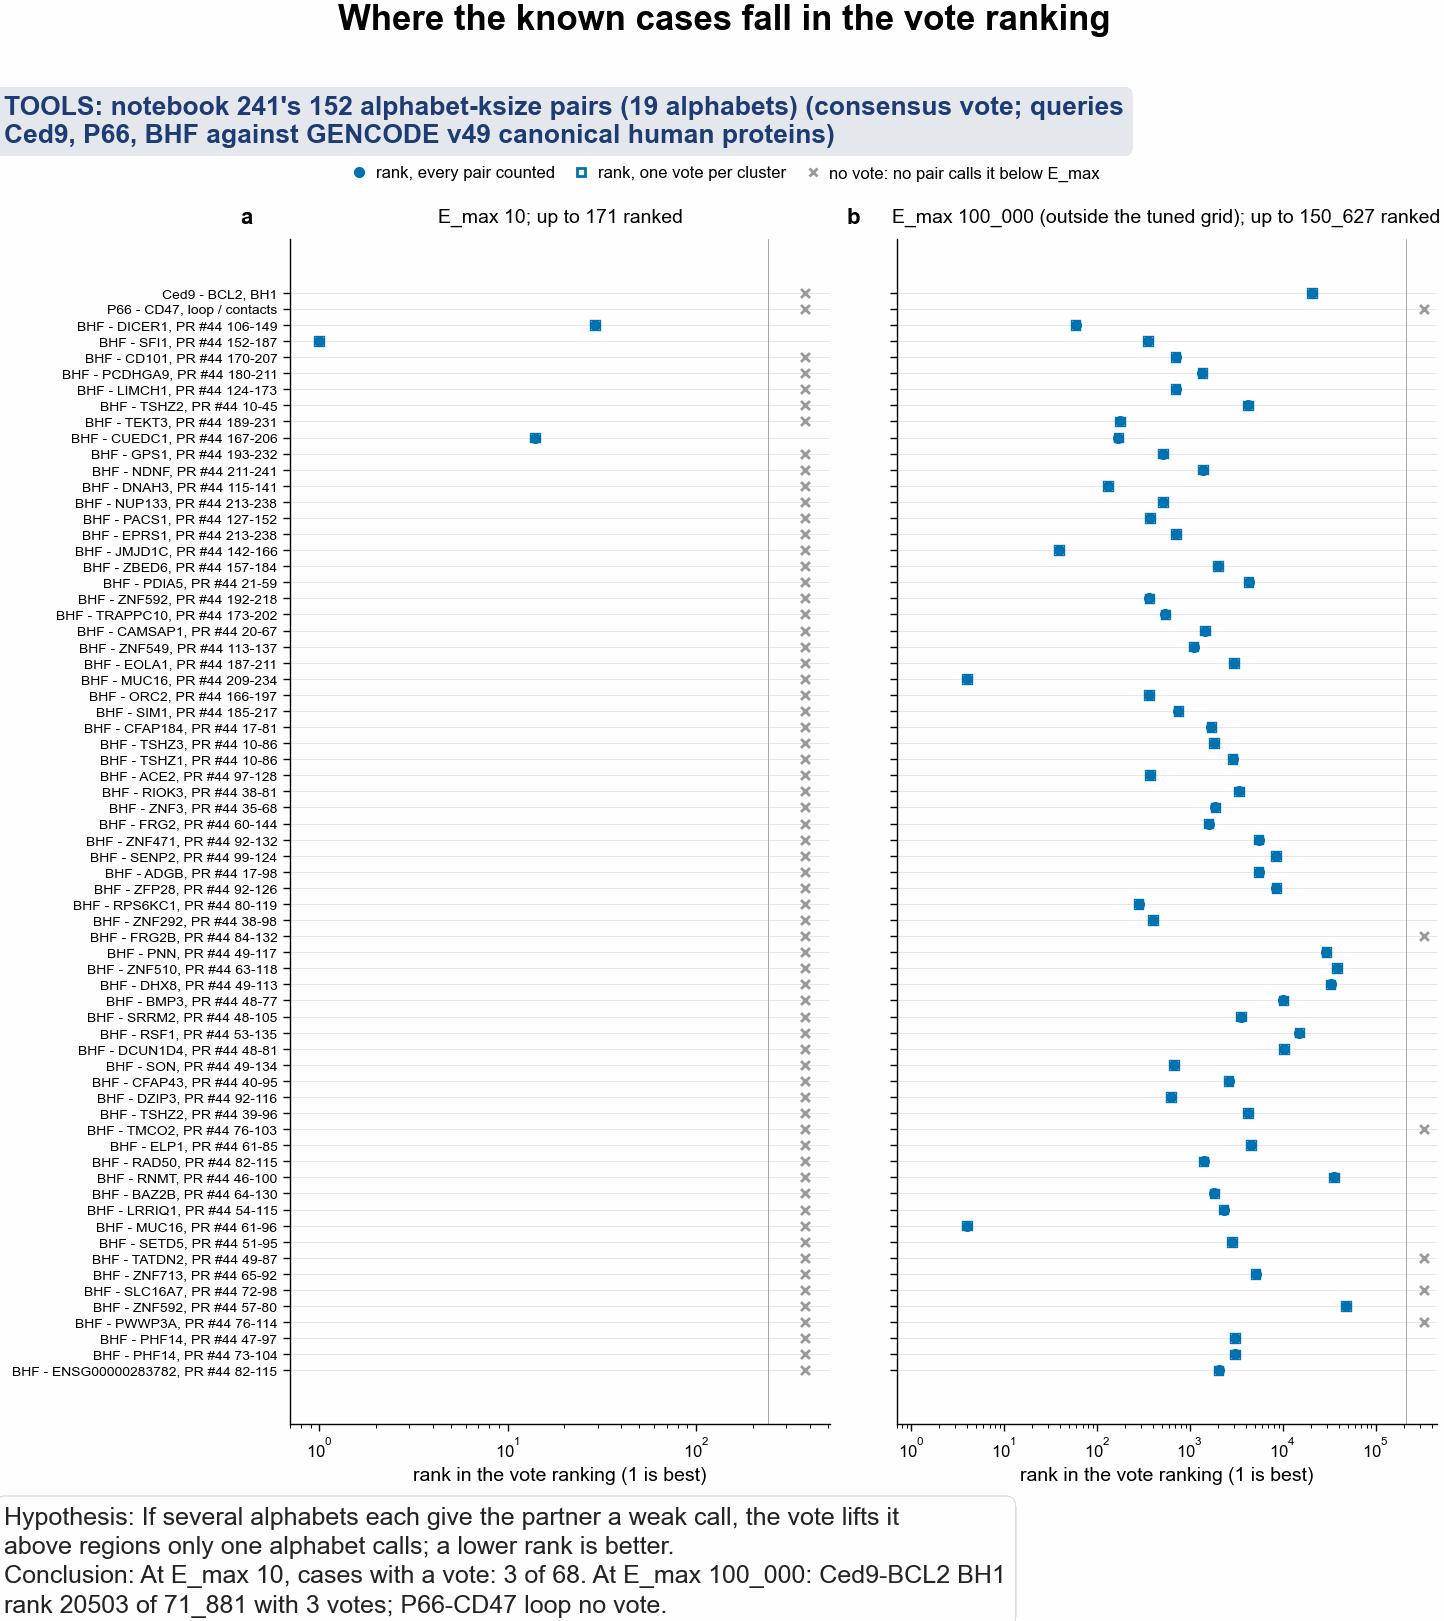

In [17]:
grid_cases = loc.select("case").unique(maintain_order=True)["case"].to_list()
rows_y = {c: i for i, c in enumerate(grid_cases)}
fig, axes = pf.figure(pf.TWO_COLUMN_MM, min(170, 30 + 2.6 * len(grid_cases)), ncols=2, sharey=True)
for ax, e, letter in zip(axes, (10.0, LOOSE), "ab"):
    d = loc.filter(pl.col("emax") == e)
    n_max = max(int(d["of_n_votes"].max() or 1), 1)
    for r in d.to_dicts():
        yv = rows_y[r["case"]]
        for col, mk in (("n_votes", "o"), ("n_cluster_votes", "s")):
            if r[f"rank_{col}"] is not None:
                ax.scatter([r[f"rank_{col}"]], [yv], marker=mk, s=12,
                           facecolors=REAL_C if col == "n_votes" else "none", edgecolors=REAL_C)
        if r["rank_n_votes"] is None:
            ax.scatter([n_max * 2.2], [yv], marker="x", s=10, color=pf.GREY, clip_on=False)
    ax.set_xscale("log")
    ax.set_xlim(0.7, n_max * 3)
    ax.axvline(n_max * 1.4, color=pf.GREY, lw=0.3)
    ax.set_xlabel("rank in the vote ranking (1 is best)")
    ax.set_title(f"E_max {e:_g}" + (" (outside the tuned grid)" if e == LOOSE else "") + f"; up to {n_max:_} ranked")
    for yv in rows_y.values():
        ax.axhline(yv, color="#DDDDDD", lw=0.3, zorder=0)
    pf.panel_label(ax, letter)
axes[0].set_yticks(list(rows_y.values()), list(rows_y), fontsize=5)
axes[0].invert_yaxis()
fig.legend([Line2D([], [], ls="none", marker="o", color=REAL_C), Line2D([], [], ls="none", marker="s", mfc="none", mec=REAL_C),
            Line2D([], [], ls="none", marker="x", color=pf.GREY)],
           ["rank, every pair counted", "rank, one vote per cluster", "no vote: no pair calls it below E_max"],
           loc="outside upper center", ncol=3)
stem = FIG / "263_vote_rank_known_cases_ced9_bcl2_p66_cd47_bhf_human_proteome"
g = loc.filter(pl.col("emax") == 10.0)
l = loc.filter(pl.col("emax") == LOOSE)
c0 = l.filter(pl.col("case") == CASES[0]["case"]).row(0, named=True)
c1 = l.filter(pl.col("case") == CASES[1]["case"]).row(0, named=True)
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=f"notebook 241's {N_TRIED} alphabet-ksize pairs (19 alphabets)", lc=False,
                        note="consensus vote; queries Ced9, P66, BHF against GENCODE v49 canonical human proteins"),
    title="Where the known cases fall in the vote ranking",
    hypothesis="If several alphabets each give the partner a weak call, the vote lifts it above "
               "regions only one alphabet calls; a lower rank is better.",
    conclusion=(f"At E_max 10, cases with a vote: {g.filter(pl.col('votes_n_votes') > 0).height} of {len(CASES)}. "
                f"At E_max {LOOSE:_.0f}: Ced9-BCL2 BH1 " +
                (f"rank {c0['rank_n_votes']} of {c0['of_n_votes']:_} with {c0['votes_n_votes']} votes" if c0['rank_n_votes'] else "no vote") +
                "; P66-CD47 loop " +
                (f"rank {c1['rank_n_votes']} of {c1['of_n_votes']:_} with {c1['votes_n_votes']} votes" if c1['rank_n_votes'] else "no vote") + "."),

)

### Agreement between notebook 241's pairs

The same agreement and clusters as section 1, on notebook 241's calls at E_max 10, for the
pairs with at least one call there. Here the pairs span 19 alphabets, so this is where
votes from related alphabets could pile up.

E_max 10: 47 pairs, 47 clusters; agreement between two pairs: median 0.000, max 0.643, pairs of pairs above 0.8: 0
shape: (0, 3)
┌─────────┬─────┬───────────┐
│ cluster ┆ n   ┆ pairs     │
│ ---     ┆ --- ┆ ---       │
│ i64     ┆ u32 ┆ list[str] │
╞═════════╪═════╪═══════════╡
└─────────┴─────┴───────────┘
E_max 100_000: 69 pairs, 68 clusters; agreement between two pairs: median 0.000, max 1.000, pairs of pairs above 0.8: 1
shape: (1, 3)
┌─────────┬─────┬───────────────────────────────────────────────────────┐
│ cluster ┆ n   ┆ pairs                                                 │
│ ---     ┆ --- ┆ ---                                                   │
│ i64     ┆ u32 ┆ list[str]                                             │
╞═════════╪═════╪═══════════════════════════════════════════════════════╡
│ 22      ┆ 2   ┆ ["hp_lehninger2_k32", "hp_lehninger_c_nonpolar2_k32"] │
└─────────┴─────┴───────────────────────────────────────────────────────┘


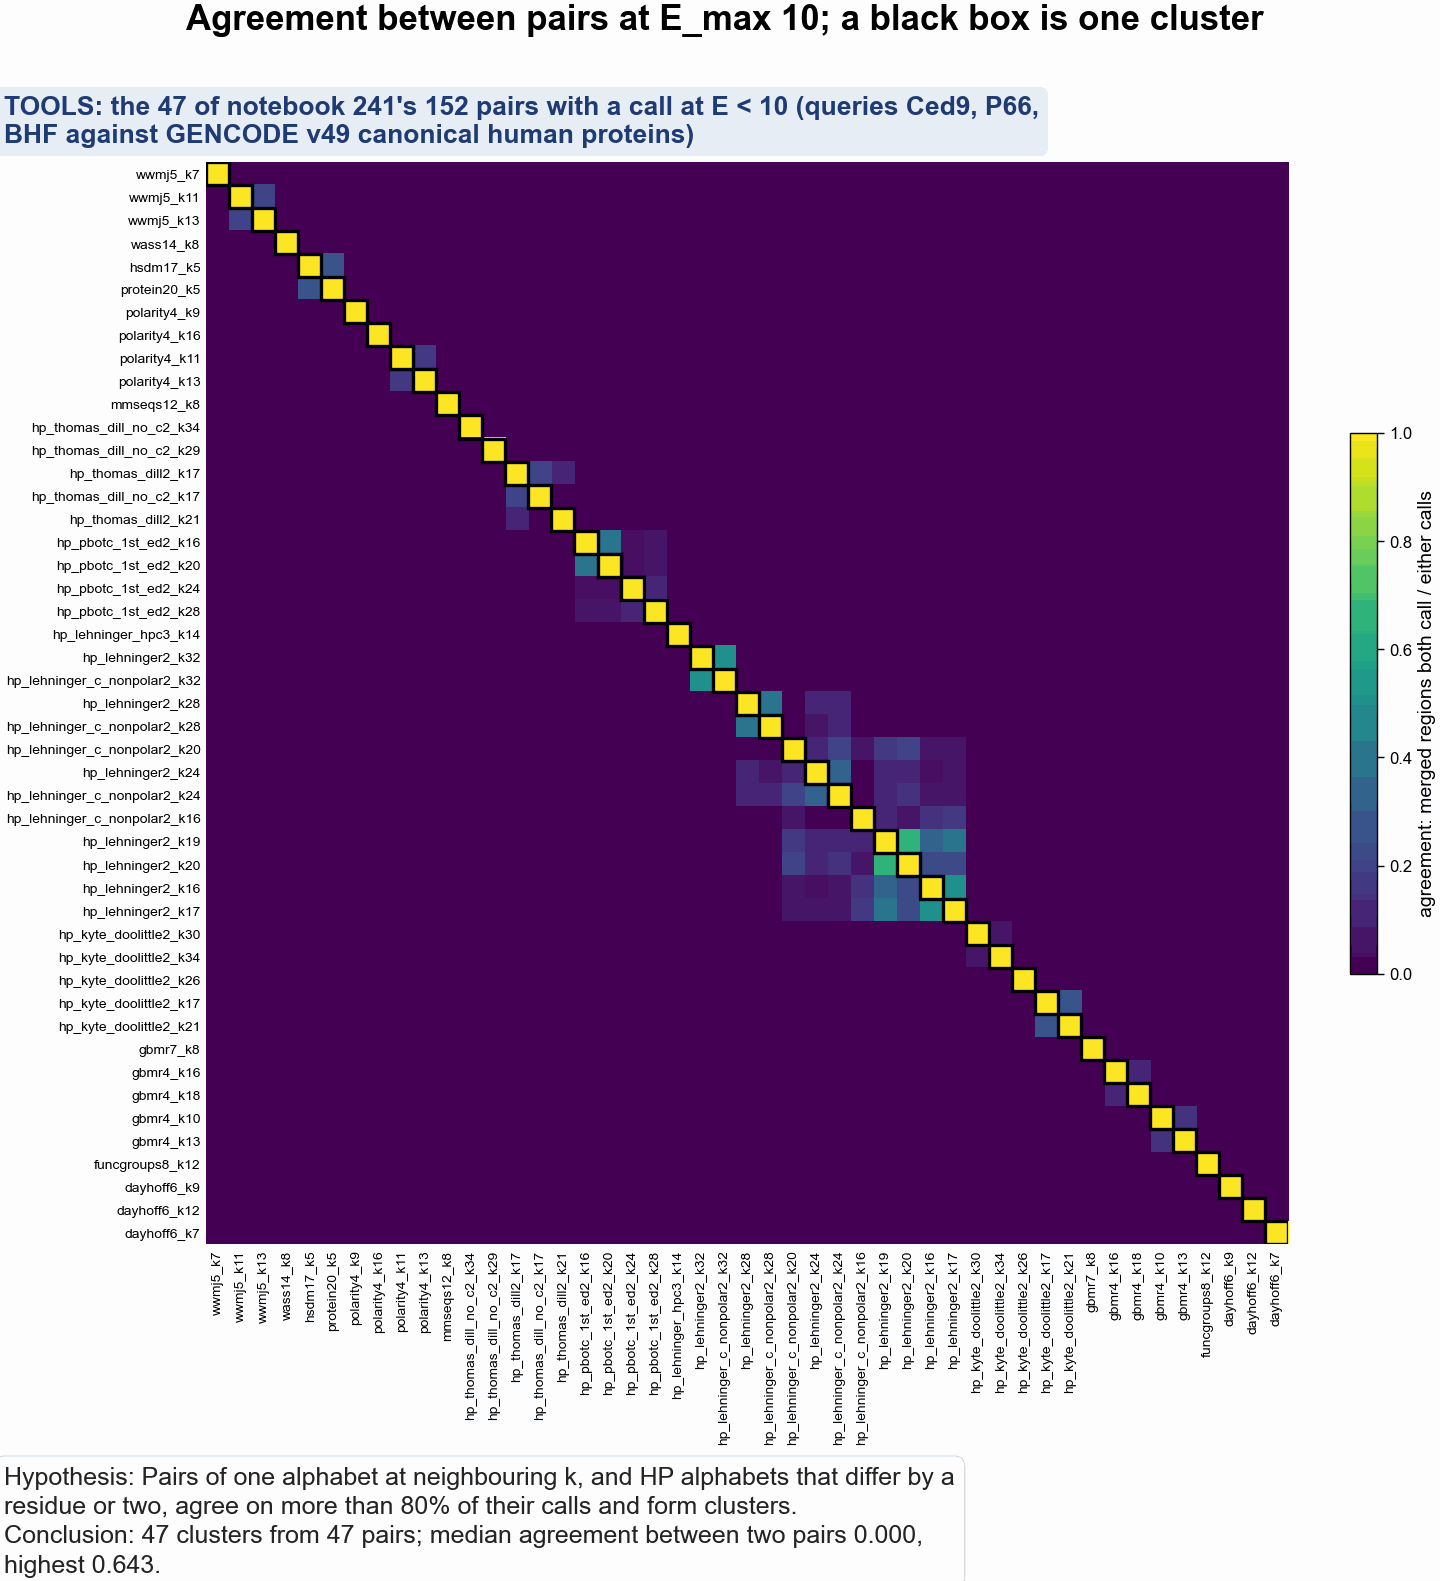

In [18]:
for e in (10.0, LOOSE):
    j, arms_e, z = CASE_AGREE[e]
    cl = CASE_CLUSTERS[e]
    off = j[~np.eye(len(arms_e), dtype=bool)]
    big = pl.DataFrame({"arm": list(cl), "cluster": list(cl.values())}).group_by("cluster").agg(
        n=pl.len(), pairs=pl.col("arm").sort()).filter(pl.col("n") > 1).sort("n", descending=True)
    print(f"E_max {e:_g}: {len(arms_e)} pairs, {len(set(cl.values()))} clusters; agreement between two pairs: "
          f"median {np.median(off):.3f}, max {off.max():.3f}, pairs of pairs above 0.8: {int((off > 0.8).sum() // 2)}")
    print(big.head(15))
j, arms_e, z = CASE_AGREE[10.0]
fig, ax = pf.figure(pf.TWO_COLUMN_MM, 165)
im = agreement_heatmap(ax, j, arms_e, CASE_CLUSTERS[10.0], z, label_size=5, annotate=False)
fig.colorbar(im, ax=ax, shrink=0.5, label="agreement: merged regions both call / either calls")
stem = FIG / "263_vote_pair_agreement_heatmap_ced9_p66_bhf_human_proteome"
off = j[~np.eye(len(arms_e), dtype=bool)]
notebook_figure(
    fig, stem,
    tools=mu.tools_text(kmerseek=f"the {len(arms_e)} of notebook 241's {N_TRIED} pairs with a call at E < 10", lc=False,
                        note="queries Ced9, P66, BHF against GENCODE v49 canonical human proteins"),
    title=f"Agreement between pairs at E_max 10; a black box is one cluster",
    hypothesis="Pairs of one alphabet at neighbouring k, and HP alphabets that differ by a residue "
               "or two, agree on more than 80% of their calls and form clusters.",
    conclusion=(f"{len(set(CASE_CLUSTERS[10.0].values()))} clusters from {len(arms_e)} pairs; median agreement "
                f"between two pairs {np.median(off):.3f}, highest {off.max():.3f}."),

)

# Summary and Conclusions

## Background

Combiner C calls a merged kmerseek region when at least v_min alphabet-ksize pairs call it
at `region_evalue` < E_max, ranking regions by vote count and then by notebook 262's
corrected E-value. This execution has notebook 260's four pairs (all hp_pbotc_1st_ed2 at
k=19 against zebrafish) and no shuffled-query run, so it tests the code and the procedure
on that table. The known cases come from notebook 241's 152-pair search against the human
proteome. The numbers below change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* The four zebrafish pairs agree on 85% to 97% of their merged regions at every E_max, so
  they form one cluster and give at most one independent vote.
* On tune at E_max 10, raising v_min from 1 to 4 drops calls from 891 to 720 and
  Swiss-Prot precision from 0.409 to 0.372; Pfam precision moves from 0.550 to 0.558.
* The rule picks v_min 1 at every E_max, because no shuffled-query calls exist and every
  setting already has Pfam precision of at least 0.5.
* The frozen vote (E_max 10, v_min 1, one vote per cluster) calls the same 822 test regions
  as combiner B, with Swiss-Prot precision 0.359 and Pfam recall 0.320.
* On 241 test queries with at least two Pfam domains, the vote lands a mean of 0.78
  domains per query, combiner A 0.68 and phmmer 2.71.
* In notebook 241's search, no pair calls BCL2's BH1 region for Ced9 at E < 10; the best
  call there, hp_lehninger2 k=19, has E = 11_173.
* No pair gives P66's 181-187 loop an E-value against CD47: the one call touching it pairs
  P66 163-181 with CD47 277-295, outside the contact span.
* Of the 66 BHF regions from PR #44, 3 get a vote at E_max 10. SFI1 152-187 ranks 1 of 97
  with 4 votes, but its corrected E-value is 128.
* At E_max 10 no two of notebook 241's 47 calling pairs agree on more than 65% of their
  calls, so one vote per cluster and one per pair give the same ranking there.

## Analysis Details

The vote is computed on notebook 262's re-merged calls: for each merged region and pair,
the lowest `region_evalue` that pair gave inside the region. A region has one vote from
each pair whose lowest E-value is below E_max. Precision, recall and the truth rule are
those of notebooks 261 and 262 (a call is true when at least half of it lies inside one
feature).

On this table the vote cannot differ from combiner B at the frozen setting. With v_min 1
and E_max 10 it calls every merged region any pair called below 10, which is what B's
threshold (corrected E-value 39.9, raw 9.97 for 4 pairs) also keeps on tune; the notebook
checks that B recomputed here calls the same 822 test regions as notebook 262's yaml.
Asking for more votes on this table removes regions that the near-copies of one search
happened to disagree on, which costs recall without raising Swiss-Prot precision.

Counting one vote per cluster or one per pair leads to the same frozen setting here, so
the rule written before running (trust one per cluster) did not have to break a tie. On
notebook 260's table the four pairs are one cluster; in notebook 241's search, at E_max 10,
each pair is its own cluster. In notebook 241's search the counts differ at E_max 0.1 (4
calling pairs, 1 cluster) and 1 (17 pairs, 11 clusters), where only 1 and 15 merged regions
have a vote, none of them a known case.

The known cases show why a vote cannot move them. A pair can only vote for a region it
calls below E_max, and across all 152 pairs and all three queries only 530 calls have
E < 10. BCL2's BH1 and CD47's contact span have no call below E = 11_173 and no call with
an E-value at all, respectively, so they get no vote at any E_max in the grid. The best
BH1 call is in register: Ced9 163-188 against BCL2 139-164 puts the G and R of BCL2's
NWGR motif opposite Ced9's G and R, with 5 of 26 residues identical and 19 more in the
same hydrophobic-polar class.

At the loose cut of 100_000, outside the grid, BH1 gets 3 votes and ranks 20_503 of
71_881. Most BHF regions get votes there too (61 of 66), but merged regions at that cut
chain across most of BHF (MUC16's covers BHF 1-252 and ranks 4), so a vote there counts
pairs that call anywhere on a long stretch, not pairs that agree on one place.

SFI1's rank 1 at E_max 10 comes from 4 pairs with E-values down to 0.84. The corrected
E-value, 152 pairs searched times 0.84, is 128, so best of n reads it as chance. No
random-protein comparison was run for the vote ranking, so rank 1 of 97 is not yet
evidence that SFI1 is a homolog.

## Supplementary Information

- Input, sections 1 to 6: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `263_consensus_vote.yaml`, checked against notebooks 261 and 262).
- Input, section 7: `~/data/botryllus/alphabet-ranking-three-cases/regions.parquet`
  (notebook 241, 2026-09-23), GENCODE v49 canonical translations, and PR #44's
  `BHF.hp_lehninger2.k24.scaled1.lcremoved.lambda-region.query_subset.csv`.
- BH1 coordinates from UniProt P41958 and P10415 (motif features), fetched 2026-10-02
  and cached under `~/data/qfo-pfam-region-midi-plus-0.4/263_consensus_vote/uniprot_cache/`.
- Residue classes for funcgroups8, mmseqs12, wass14 and hsdm17 from kmerseek's
  `src/rust/alphabets.rs` (seanome/kmerseek d79f863); the rest from `hp_conservation_utils`.
- Code: `notebooks/region_combiner_263.py`, `notebooks/263_build_notebook.py`; figures
  use `notebooks/pubfig.py` and `notebooks/nature.mplstyle`.
- To rebuild on the full run: reduce the extension run and its `M04_RUN=decoy` twin with
  notebook 260's code (shuffled calls in `260_region_table/reduced_decoy/`), then
  re-execute notebooks 261, 262 and 263.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb), [notebook 261](261_combiner_a_intersection_panel.ipynb)
  and [notebook 262](262_combiner_b_best_of_n.ipynb): the region table, combiner A and combiner B.
- [Notebook 241](https://github.com/seanome/2024-kmerseek-analysis/pull/46): the 152-pair
  search of Ced9, P66 and BHF against the human proteome.
- [PR #44](https://github.com/seanome/2024-kmerseek-analysis/pull/44): the BHF regions.
- [Notebook 245](https://github.com/seanome/2024-kmerseek-analysis/pull/96): the P66 loop
  and CD47 contact span.

In [19]:
summary_md = r"""
# Summary and Conclusions

## Background

Combiner C calls a merged kmerseek region when at least v_min alphabet-ksize pairs call it
at `region_evalue` < E_max, ranking regions by vote count and then by notebook 262's
corrected E-value. This execution has notebook 260's four pairs (all hp_pbotc_1st_ed2 at
k=19 against zebrafish) and no shuffled-query run, so it tests the code and the procedure
on that table. The known cases come from notebook 241's 152-pair search against the human
proteome. The numbers below change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* The four zebrafish pairs agree on 85% to 97% of their merged regions at every E_max, so
  they form one cluster and give at most one independent vote.
* On tune at E_max 10, raising v_min from 1 to 4 drops calls from 891 to 720 and
  Swiss-Prot precision from 0.409 to 0.372; Pfam precision moves from 0.550 to 0.558.
* The rule picks v_min 1 at every E_max, because no shuffled-query calls exist and every
  setting already has Pfam precision of at least 0.5.
* The frozen vote (E_max 10, v_min 1, one vote per cluster) calls the same 822 test regions
  as combiner B, with Swiss-Prot precision 0.359 and Pfam recall 0.320.
* On 241 test queries with at least two Pfam domains, the vote lands a mean of 0.78
  domains per query, combiner A 0.68 and phmmer 2.71.
* In notebook 241's search, no pair calls BCL2's BH1 region for Ced9 at E < 10; the best
  call there, hp_lehninger2 k=19, has E = 11_173.
* No pair gives P66's 181-187 loop an E-value against CD47: the one call touching it pairs
  P66 163-181 with CD47 277-295, outside the contact span.
* Of the 66 BHF regions from PR #44, 3 get a vote at E_max 10. SFI1 152-187 ranks 1 of 97
  with 4 votes, but its corrected E-value is 128.
* At E_max 10 no two of notebook 241's 47 calling pairs agree on more than 65% of their
  calls, so one vote per cluster and one per pair give the same ranking there.

## Analysis Details

The vote is computed on notebook 262's re-merged calls: for each merged region and pair,
the lowest `region_evalue` that pair gave inside the region. A region has one vote from
each pair whose lowest E-value is below E_max. Precision, recall and the truth rule are
those of notebooks 261 and 262 (a call is true when at least half of it lies inside one
feature).

On this table the vote cannot differ from combiner B at the frozen setting. With v_min 1
and E_max 10 it calls every merged region any pair called below 10, which is what B's
threshold (corrected E-value 39.9, raw 9.97 for 4 pairs) also keeps on tune; the notebook
checks that B recomputed here calls the same 822 test regions as notebook 262's yaml.
Asking for more votes on this table removes regions that the near-copies of one search
happened to disagree on, which costs recall without raising Swiss-Prot precision.

Counting one vote per cluster or one per pair leads to the same frozen setting here, so
the rule written before running (trust one per cluster) did not have to break a tie. On
notebook 260's table the four pairs are one cluster; in notebook 241's search, at E_max 10,
each pair is its own cluster. In notebook 241's search the counts differ at E_max 0.1 (4
calling pairs, 1 cluster) and 1 (17 pairs, 11 clusters), where only 1 and 15 merged regions
have a vote, none of them a known case.

The known cases show why a vote cannot move them. A pair can only vote for a region it
calls below E_max, and across all 152 pairs and all three queries only 530 calls have
E < 10. BCL2's BH1 and CD47's contact span have no call below E = 11_173 and no call with
an E-value at all, respectively, so they get no vote at any E_max in the grid. The best
BH1 call is in register: Ced9 163-188 against BCL2 139-164 puts the G and R of BCL2's
NWGR motif opposite Ced9's G and R, with 5 of 26 residues identical and 19 more in the
same hydrophobic-polar class.

At the loose cut of 100_000, outside the grid, BH1 gets 3 votes and ranks 20_503 of
71_881. Most BHF regions get votes there too (61 of 66), but merged regions at that cut
chain across most of BHF (MUC16's covers BHF 1-252 and ranks 4), so a vote there counts
pairs that call anywhere on a long stretch, not pairs that agree on one place.

SFI1's rank 1 at E_max 10 comes from 4 pairs with E-values down to 0.84. The corrected
E-value, 152 pairs searched times 0.84, is 128, so best of n reads it as chance. No
random-protein comparison was run for the vote ranking, so rank 1 of 97 is not yet
evidence that SFI1 is a homolog.

## Supplementary Information

- Input, sections 1 to 6: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `263_consensus_vote.yaml`, checked against notebooks 261 and 262).
- Input, section 7: `~/data/botryllus/alphabet-ranking-three-cases/regions.parquet`
  (notebook 241, 2026-09-23), GENCODE v49 canonical translations, and PR #44's
  `BHF.hp_lehninger2.k24.scaled1.lcremoved.lambda-region.query_subset.csv`.
- BH1 coordinates from UniProt P41958 and P10415 (motif features), fetched 2026-10-02
  and cached under `~/data/qfo-pfam-region-midi-plus-0.4/263_consensus_vote/uniprot_cache/`.
- Residue classes for funcgroups8, mmseqs12, wass14 and hsdm17 from kmerseek's
  `src/rust/alphabets.rs` (seanome/kmerseek d79f863); the rest from `hp_conservation_utils`.
- Code: `notebooks/region_combiner_263.py`, `notebooks/263_build_notebook.py`; figures
  use `notebooks/pubfig.py` and `notebooks/nature.mplstyle`.
- To rebuild on the full run: reduce the extension run and its `M04_RUN=decoy` twin with
  notebook 260's code (shuffled calls in `260_region_table/reduced_decoy/`), then
  re-execute notebooks 261, 262 and 263.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb), [notebook 261](261_combiner_a_intersection_panel.ipynb)
  and [notebook 262](262_combiner_b_best_of_n.ipynb): the region table, combiner A and combiner B.
- [Notebook 241](https://github.com/seanome/2024-kmerseek-analysis/pull/46): the 152-pair
  search of Ced9, P66 and BHF against the human proteome.
- [PR #44](https://github.com/seanome/2024-kmerseek-analysis/pull/44): the BHF regions.
- [Notebook 245](https://github.com/seanome/2024-kmerseek-analysis/pull/96): the P66 loop
  and CD47 contact span.
"""
print(summary_md)


# Summary and Conclusions

## Background

Combiner C calls a merged kmerseek region when at least v_min alphabet-ksize pairs call it
at `region_evalue` < E_max, ranking regions by vote count and then by notebook 262's
corrected E-value. This execution has notebook 260's four pairs (all hp_pbotc_1st_ed2 at
k=19 against zebrafish) and no shuffled-query run, so it tests the code and the procedure
on that table. The known cases come from notebook 241's 152-pair search against the human
proteome. The numbers below change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* The four zebrafish pairs agree on 85% to 97% of their merged regions at every E_max, so
  they form one cluster and give at most one independent vote.
* On tune at E_max 10, raising v_min from 1 to 4 drops calls from 891 to 720 and
  Swiss-Prot precision from 0.409 to 0.372; Pfam precision moves from 0.550 to 0.558.
* The rule picks v_min 1 at every E_max, because no shuffled-query calls exist and